# P/E Ratio Prediction - Complete EDA & ML Pipeline

## Project Objective
Develop a robust and interpretable machine learning framework to predict the **Price-to-Earnings (P/E) ratio** of Nifty 500 companies using their 2024 financial, ownership, balance-sheet, and market structure characteristics.

## Notebook Structure (Corrected Flow)
1. **Load Data** - Import dataset
2. **RAW EDA** - Explore data BEFORE any cleaning
3. **Data Cleaning** - Remove outliers, transform target (ONE place only)
4. **Cleaned EDA** - Verify cleaning worked
5. **Preprocessing** - Encode, scale features
6. **Model Building** - Train and evaluate models

In [1]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost lightgbm catboost tqdm


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# STEP 1: LOAD DATA & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

RANDOM_SEED = 42

# Load the dataset
file_path = 'E:\\OffCampus Placement\\Predicting PE Ratio\\Final with sectors only.csv'
df_raw = pd.read_csv(file_path)

# Store original for reference
df = df_raw.copy()

print("="*70)
print(" DATASET LOADED SUCCESSFULLY")
print("="*70)
print(f"\n Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n Columns ({len(df.columns)}):")
print(df.columns.tolist())
print("\n First 5 rows:")
df.head()

 DATASET LOADED SUCCESSFULLY

 Shape: 390 rows × 18 columns

 Columns (18):
['Company_Name', 'Promoter_Holding', 'Promoter_Pledged', 'Institutional_Holding', 'Sales', 'Sales_Growth_Pct', 'BVPS', 'BV_Growth_Pct', 'Total_Equity', 'Profit', 'Profit_Growth_Pct', 'Other_Income', 'Total_Expenses', 'RnD_Expenses', 'Beta', 'P_E', 'StockReturnPct', 'Sector']

 First 5 rows:


,Company_Name,Promoter_Holding,Promoter_Pledged,Institutional_Holding,Sales,Sales_Growth_Pct,BVPS,BV_Growth_Pct,Total_Equity,Profit,Profit_Growth_Pct,Other_Income,Total_Expenses,RnD_Expenses,Beta,P_E,StockReturnPct,Sector
0,3M India Ltd.,75.00,0.00,12.07,39267.70,5.18,2104.01,21.68,23701.90,5362.70,28.87,30.90,34201.20,455.20,0.81,65.24,35.12,Industrials
1,A B B India Ltd.,75.00,0.00,17.84,104465.20,21.93,302.20,26.36,59446.00,12420.50,22.22,246.60,95505.90,0.00,0.80,96.61,91.36,Industrials
2,A C C Ltd.,56.69,0.00,30.97,221673.20,-11.24,852.64,14.10,160219.50,21242.40,144.19,85.20,207846.10,23.00,1.00,28.80,43.62,Materials
3,A I A Engineering Ltd.,58.47,0.00,38.71,41487.00,2.55,684.46,17.96,64558.30,11294.50,16.58,3.20,34085.70,0.00,0.64,31.80,39.67,Industrials
4,A P L Apollo Tubes Ltd.,29.44,0.00,44.75,143737.70,-3.03,104.11,12.31,28893.90,4537.10,-11.37,106.20,138382.60,0.00,1.25,96.47,30.31,Materials


---
## STEP 2: RAW EDA (Before Any Cleaning)
Explore the raw data to understand distributions, outliers, and data quality issues BEFORE making any changes.

In [3]:
# 2.1 Basic Overview - Data Types & Missing Values
print("="*70)
print(" DATA TYPES & INFO")
print("="*70)
df.info()

print("\n" + "="*70)
print(" MISSING VALUES ANALYSIS")
print("="*70)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Dtype': df.dtypes.values
})
print(missing_df.to_string(index=False))

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
df.describe().T

 DATA TYPES & INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company_Name           390 non-null    object 
 1   Promoter_Holding       390 non-null    float64
 2   Promoter_Pledged       390 non-null    float64
 3   Institutional_Holding  390 non-null    float64
 4   Sales                  390 non-null    float64
 5   Sales_Growth_Pct       390 non-null    float64
 6   BVPS                   390 non-null    float64
 7   BV_Growth_Pct          390 non-null    float64
 8   Total_Equity           390 non-null    float64
 9   Profit                 390 non-null    float64
 10  Profit_Growth_Pct      390 non-null    float64
 11  Other_Income           390 non-null    float64
 12  Total_Expenses         390 non-null    float64
 13  RnD_Expenses           390 non-null    float64
 14  Beta                   390 non-null    

,count,mean,std,min,25%,50%,75%,max
Promoter_Holding,390.00,54.18,17.53,0.00,45.34,55.00,67.26,90.00
Promoter_Pledged,390.00,2.81,11.62,0.00,0.00,0.00,0.00,99.99
Institutional_Holding,390.00,28.71,15.83,1.06,17.63,27.21,37.73,89.30
Sales,390.00,200768.29,668935.05,62.90,23883.65,50287.60,119883.50,8656459.20
Sales_Growth_Pct,390.00,10.51,50.39,-97.70,-1.83,7.43,16.10,893.36
BVPS,390.00,387.11,2012.86,-134.10,71.66,158.20,305.98,38764.67
BV_Growth_Pct,390.00,14.78,32.89,-211.09,5.09,12.26,19.51,311.28
Total_Equity,390.00,125164.51,362460.13,-1036440.00,20522.55,38988.05,98896.17,5150960.00
Profit,390.00,18899.02,54785.38,-312362.00,2599.00,5317.05,13207.45,435590.00
Profit_Growth_Pct,390.00,-17.22,722.30,-12251.01,-13.47,14.95,42.68,2596.71


 SECTOR DISTRIBUTION (RAW DATA)

Number of unique sectors: 10

Sector
Industrials               99
Materials                 74
Consumer Discretionary    55
Healthcare                43
Information Technology    36
Consumer Staples          31
Utilities                 18
Energy                    15
Communication Services    12
Financials                 7
Name: count, dtype: int64


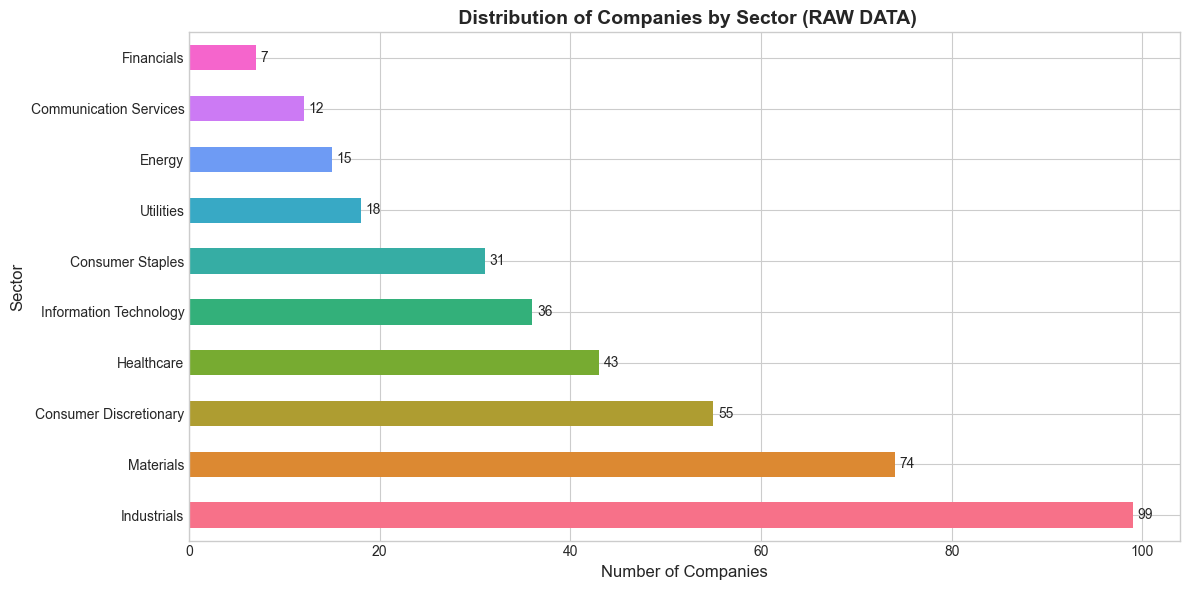

In [4]:
# 2.2 Sector Distribution (RAW)
print("="*70)
print(" SECTOR DISTRIBUTION (RAW DATA)")
print("="*70)
sector_counts = df['Sector'].value_counts()
print(f"\nNumber of unique sectors: {df['Sector'].nunique()}\n")
print(sector_counts)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("husl", len(sector_counts))
sector_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of Companies', fontsize=12)
ax.set_ylabel('Sector', fontsize=12)
ax.set_title(' Distribution of Companies by Sector (RAW DATA)', fontsize=14, fontweight='bold')
for i, v in enumerate(sector_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

 RAW P/E DISTRIBUTION (BEFORE ANY CLEANING)

 RAW P/E Statistics:
   Count:    390
   Mean:     97.13
   Median:   49.12
   Std:      458.26
   Min:      0.00
   Max:      8839.48
   Skewness: 18.04
   Kurtosis: 343.06

 Problematic Values:
   P/E = 0:  25 companies
   P/E < 0:  0 companies


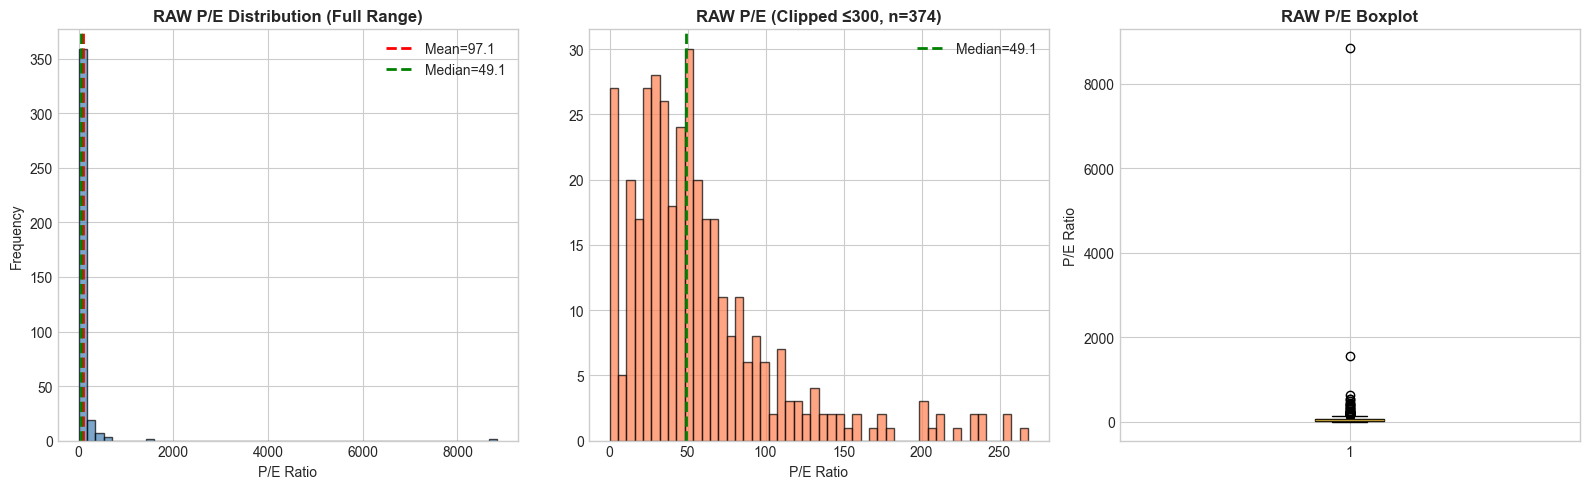


 DIAGNOSIS: Large gap between Mean and Median indicates SEVERE RIGHT SKEWNESS
 ACTION NEEDED: Remove P/E=0, remove outliers, apply log transformation


In [5]:
# 2.3 RAW P/E Distribution (TARGET VARIABLE - BEFORE CLEANING)
print("="*70)
print(" RAW P/E DISTRIBUTION (BEFORE ANY CLEANING)")
print("="*70)

# Statistics on RAW data
print(f"\n RAW P/E Statistics:")
print(f"   Count:    {df['P_E'].count()}")
print(f"   Mean:     {df['P_E'].mean():.2f}")
print(f"   Median:   {df['P_E'].median():.2f}")
print(f"   Std:      {df['P_E'].std():.2f}")
print(f"   Min:      {df['P_E'].min():.2f}")
print(f"   Max:      {df['P_E'].max():.2f}")
print(f"   Skewness: {df['P_E'].skew():.2f}")
print(f"   Kurtosis: {df['P_E'].kurtosis():.2f}")

# Count problematic values
zero_pe = (df['P_E'] == 0).sum()
negative_pe = (df['P_E'] < 0).sum()
print(f"\n Problematic Values:")
print(f"   P/E = 0:  {zero_pe} companies")
print(f"   P/E < 0:  {negative_pe} companies")

# Plot RAW distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Full histogram
ax1 = axes[0]
ax1.hist(df['P_E'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['P_E'].mean(), color='red', linestyle='--', lw=2, label=f'Mean={df["P_E"].mean():.1f}')
ax1.axvline(df['P_E'].median(), color='green', linestyle='--', lw=2, label=f'Median={df["P_E"].median():.1f}')
ax1.set_title('RAW P/E Distribution (Full Range)', fontsize=12, fontweight='bold')
ax1.set_xlabel('P/E Ratio')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Clipped view (0-300)
ax2 = axes[1]
df_clipped = df[df['P_E'] <= 300]['P_E']
ax2.hist(df_clipped, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(df['P_E'].median(), color='green', linestyle='--', lw=2, label=f'Median={df["P_E"].median():.1f}')
ax2.set_title(f'RAW P/E (Clipped ≤300, n={len(df_clipped)})', fontsize=12, fontweight='bold')
ax2.set_xlabel('P/E Ratio')
ax2.legend()

# 3. Boxplot
ax3 = axes[2]
ax3.boxplot(df['P_E'], vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightcoral'))
ax3.set_title('RAW P/E Boxplot', fontsize=12, fontweight='bold')
ax3.set_ylabel('P/E Ratio')

plt.tight_layout()
plt.show()

print("\n DIAGNOSIS: Large gap between Mean and Median indicates SEVERE RIGHT SKEWNESS")
print(" ACTION NEEDED: Remove P/E=0, remove outliers, apply log transformation")

In [6]:
# 2.4 RAW Outlier Analysis (IQR Method)
print("="*70)
print(" RAW OUTLIER ANALYSIS (IQR METHOD)")
print("="*70)

# IQR calculation on RAW data
Q1 = df['P_E'].quantile(0.25)
Q3 = df['P_E'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

outliers_raw = df[(df['P_E'] < lower_bound) | (df['P_E'] > upper_bound)]

print(f"\n IQR Analysis (RAW DATA):")
print(f"   Q1 (25%):      {Q1:.2f}")
print(f"   Q3 (75%):      {Q3:.2f}")
print(f"   IQR:           {IQR:.2f}")
print(f"   Lower Bound:   {lower_bound:.2f}")
print(f"   Upper Bound:   {upper_bound:.2f}")
print(f"   Outliers:      {len(outliers_raw)} ({len(outliers_raw)/len(df)*100:.1f}%)")

# Show extreme outliers
print("\n TOP 10 EXTREME P/E VALUES (RAW):")
extreme = df.nlargest(10, 'P_E')[['Company_Name', 'Sector', 'P_E', 'Profit', 'Sales']]
print(extreme.to_string(index=False))

print("\n BOTTOM 10 P/E VALUES (RAW):")
low = df.nsmallest(10, 'P_E')[['Company_Name', 'Sector', 'P_E', 'Profit', 'Sales']]
print(low.to_string(index=False))

 RAW OUTLIER ANALYSIS (IQR METHOD)

 IQR Analysis (RAW DATA):
   Q1 (25%):      27.10
   Q3 (75%):      78.28
   IQR:           51.18
   Lower Bound:   0.00
   Upper Bound:   155.05
   Outliers:      37 (9.5%)

 TOP 10 EXTREME P/E VALUES (RAW):
                          Company_Name                 Sector     P_E  Profit    Sales
                      Swan Energy Ltd.                 Energy 8839.48   21.70  3858.20
                      P B Fintech Ltd.             Financials 1565.35  361.90  1102.90
                           Biocon Ltd.             Healthcare  633.28 1193.00 21086.00
                   Rajesh Exports Ltd. Consumer Discretionary  550.21  170.30 54018.40
                            Sobha Ltd. Consumer Discretionary  548.74  465.70 31010.50
            Devyani International Ltd. Consumer Discretionary  483.34  -63.40 31189.50
           Syrma S G S Technology Ltd. Information Technology  457.85  200.30 18354.90
        F S N E-Commerce Ventures Ltd. Consumer Discretiona

 RAW P/E BY SECTOR
                         mean  median     std  min     max  count
Sector                                                           
Consumer Discretionary 102.45   67.99  127.46 0.00  550.21     55
Consumer Staples        62.30   58.06   38.55 0.00  160.51     31
Healthcare              87.60   54.73  112.37 0.00  633.28     43
Industrials             74.47   50.63   76.62 0.00  388.88     99
Financials             313.70   50.57  570.81 0.00 1565.35      7
Information Technology  72.98   48.21   83.72 0.00  457.85     36
Materials               52.40   41.87   52.34 0.00  307.80     74
Communication Services  43.14   37.66   42.41 0.00  128.83     12
Utilities               43.17   22.10   53.72 0.00  200.45     18
Energy                 612.03   12.04 2276.26 4.62 8839.48     15


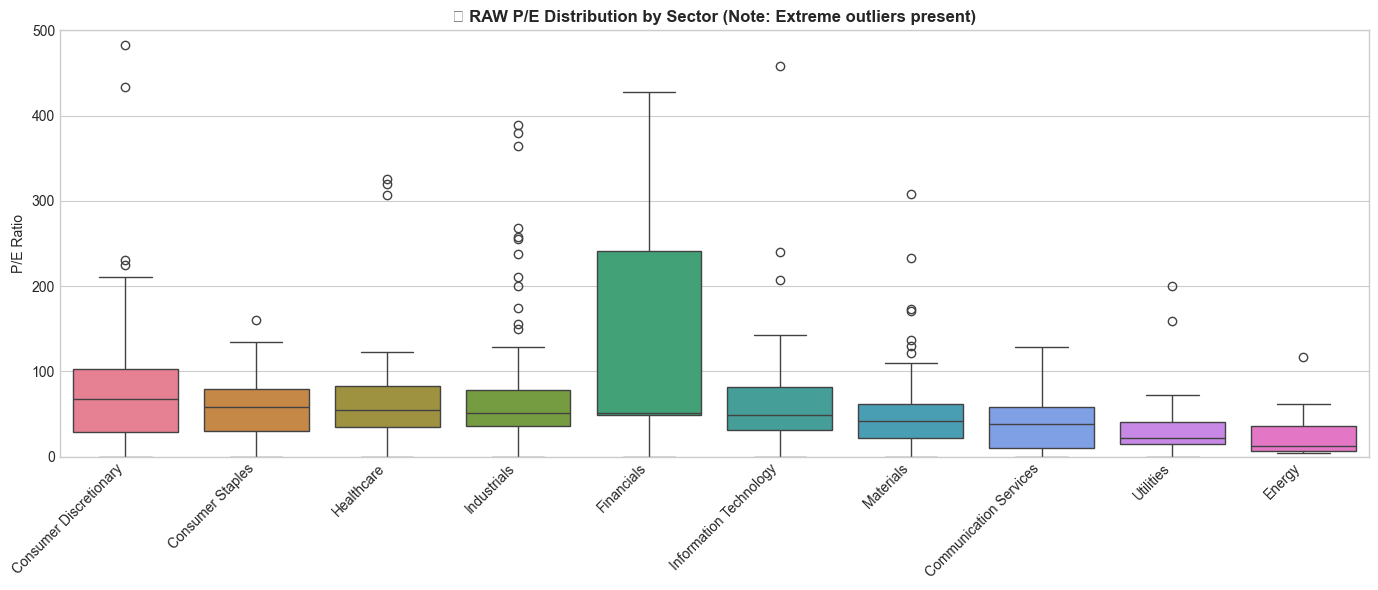

In [7]:
# 2.5 RAW P/E by Sector Analysis
print("="*70)
print(" RAW P/E BY SECTOR")
print("="*70)

# Sector-wise P/E statistics (RAW)
sector_pe_raw = df.groupby('Sector')['P_E'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
sector_pe_raw = sector_pe_raw.sort_values('median', ascending=False)
print(sector_pe_raw.round(2))

# Boxplot by Sector (RAW)
fig, ax = plt.subplots(figsize=(14, 6))
sector_order = sector_pe_raw.index.tolist()
sns.boxplot(data=df, x='Sector', y='P_E', order=sector_order, ax=ax, palette='husl')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('📦 RAW P/E Distribution by Sector (Note: Extreme outliers present)', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('P/E Ratio')
ax.set_ylim(0, 500)  # Clip for visibility
plt.tight_layout()
plt.show()

 RAW NUMERIC FEATURES (16 columns)
['Promoter_Holding', 'Promoter_Pledged', 'Institutional_Holding', 'Sales', 'Sales_Growth_Pct', 'BVPS', 'BV_Growth_Pct', 'Total_Equity', 'Profit', 'Profit_Growth_Pct', 'Other_Income', 'Total_Expenses', 'RnD_Expenses', 'Beta', 'P_E', 'StockReturnPct']


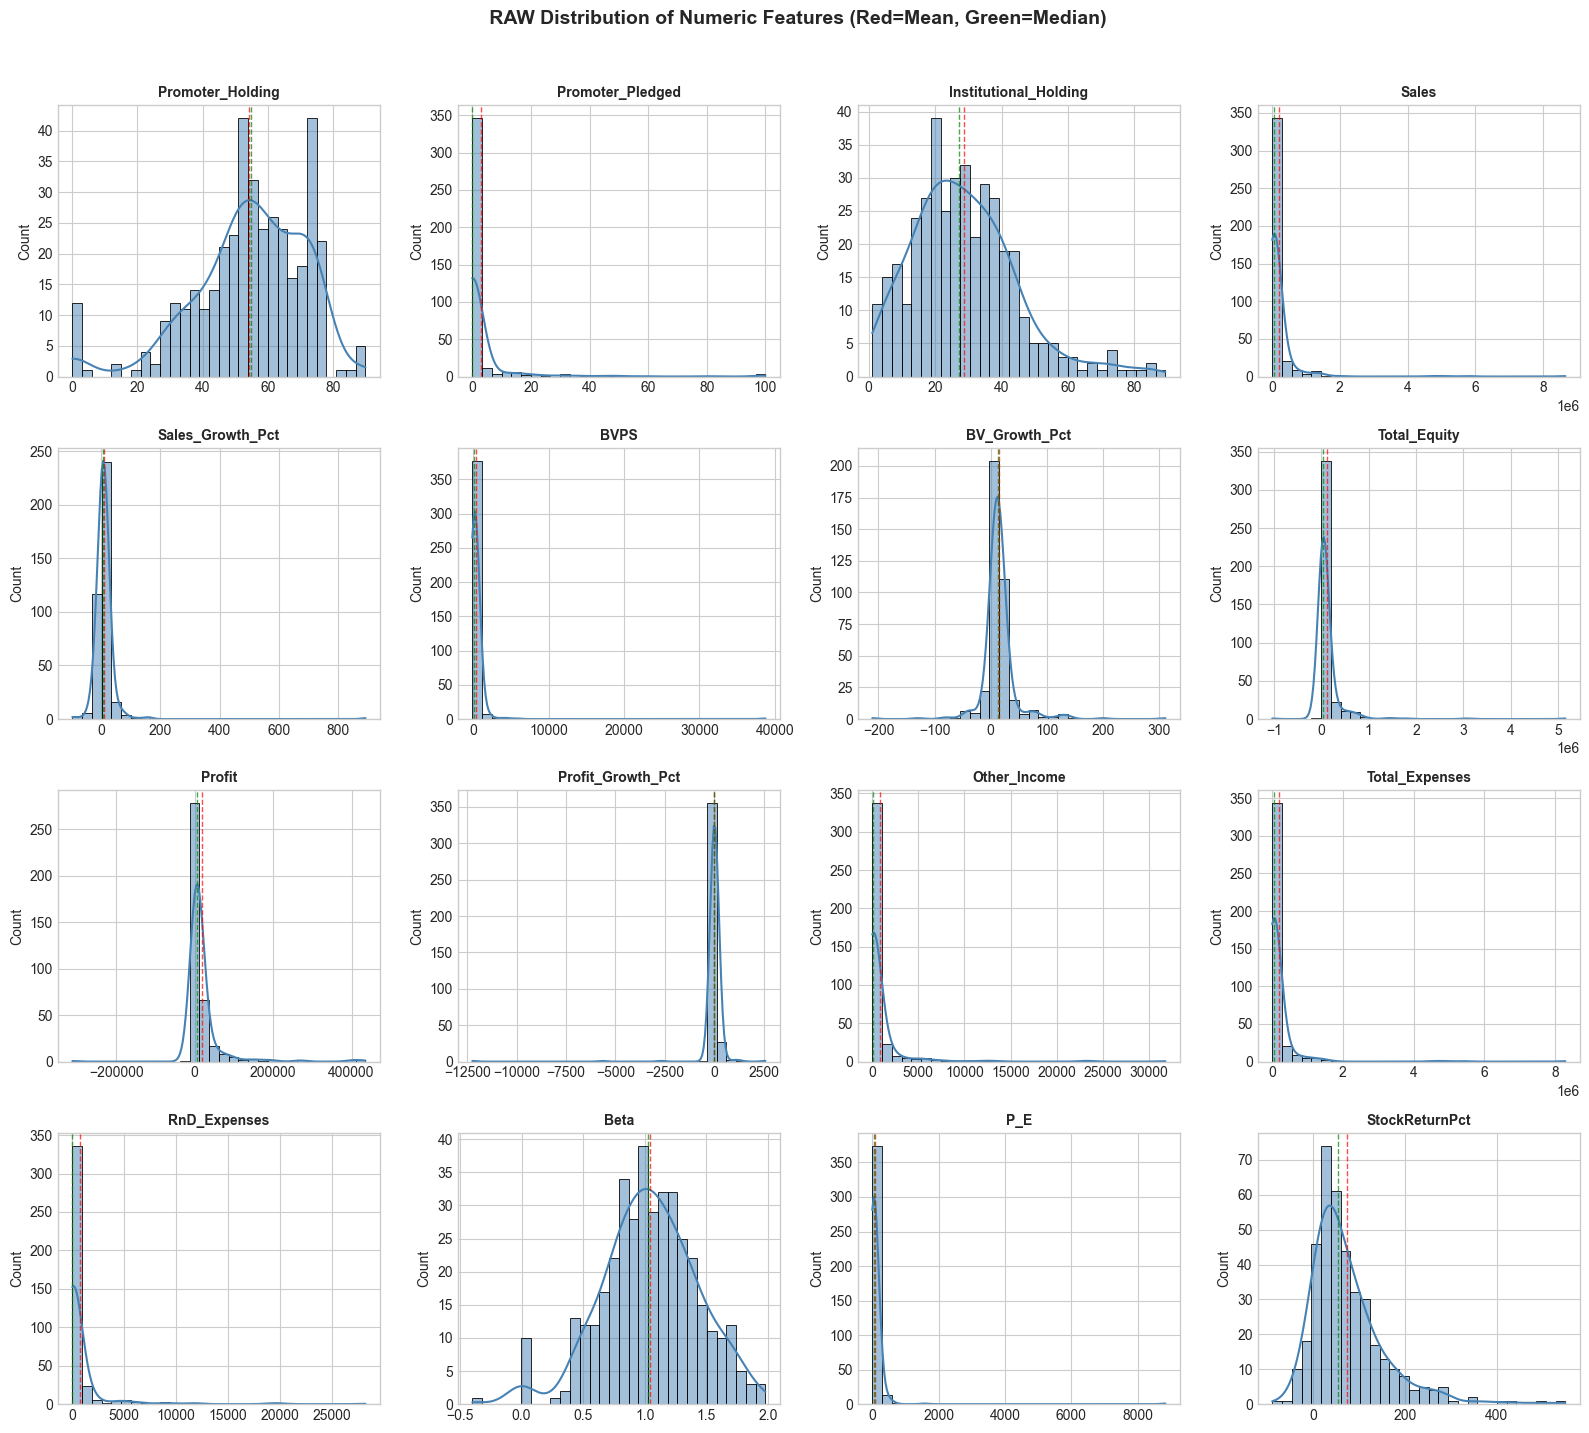

In [8]:
# 2.6 RAW Univariate EDA - All Numeric Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("="*70)
print(f" RAW NUMERIC FEATURES ({len(numeric_cols)} columns)")
print("="*70)
print(numeric_cols)

# Distribution plots
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(' RAW Distribution of Numeric Features (Red=Mean, Green=Median)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

 RAW CORRELATION MATRIX


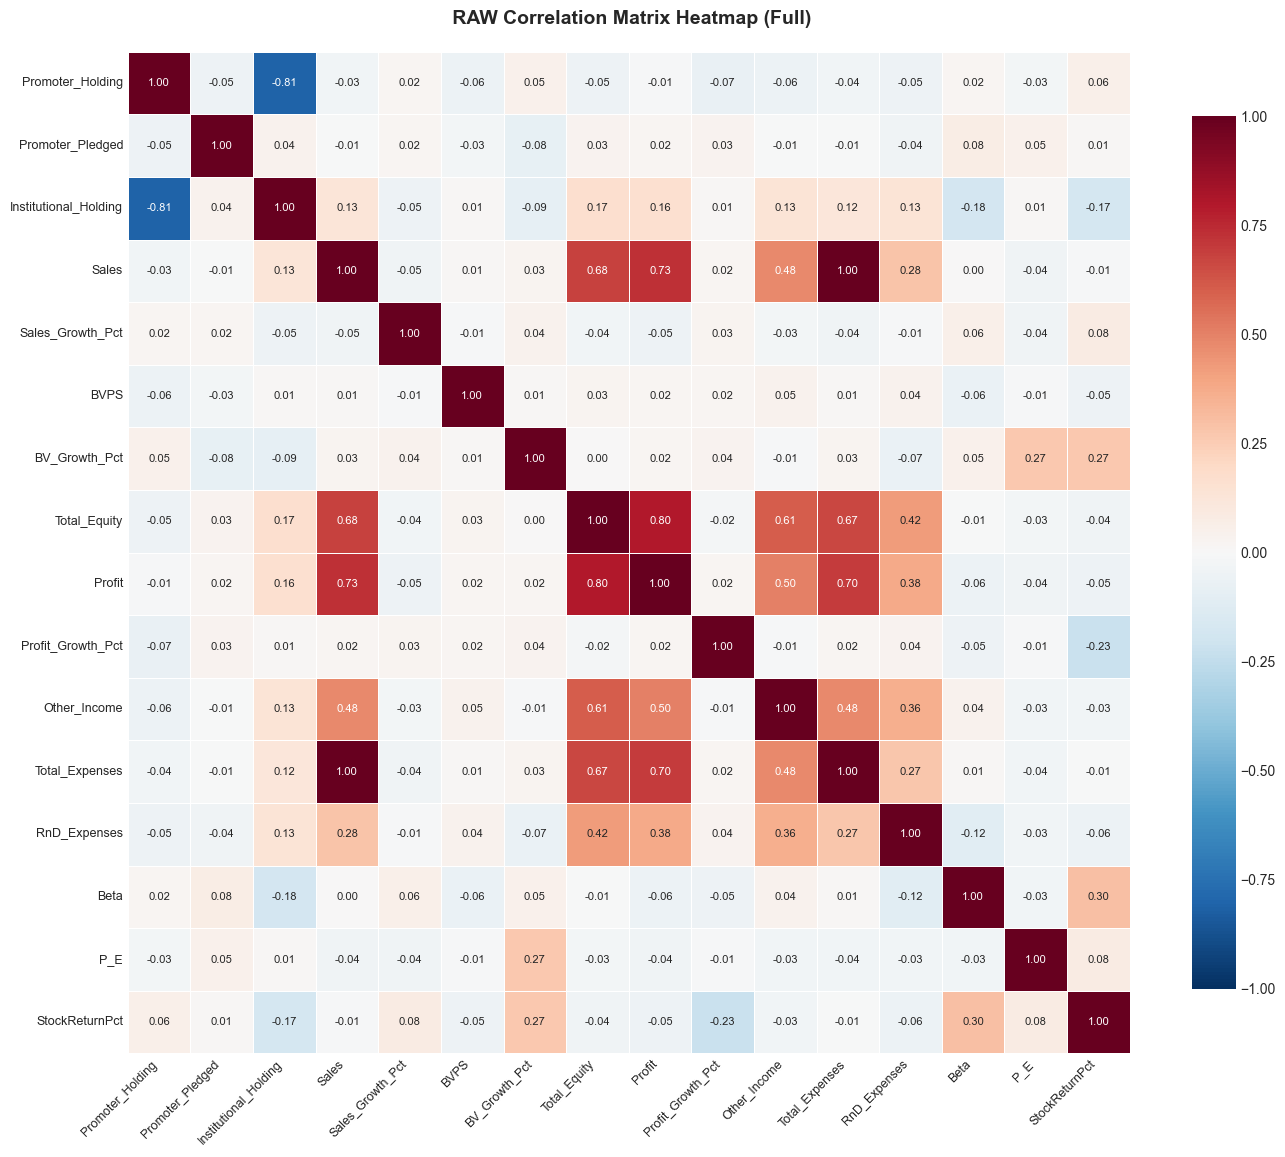


🎯 CORRELATIONS WITH P/E (Target):
BV_Growth_Pct            0.27
StockReturnPct           0.08
Promoter_Pledged         0.05
Profit                  -0.04
Sales_Growth_Pct        -0.04
Sales                   -0.04
Total_Expenses          -0.04
Beta                    -0.03
Other_Income            -0.03
RnD_Expenses            -0.03
Promoter_Holding        -0.03
Total_Equity            -0.03
BVPS                    -0.01
Profit_Growth_Pct       -0.01
Institutional_Holding    0.01

 HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7):
       Feature 1             Feature 2  Correlation
           Sales        Total_Expenses         1.00
    Total_Equity                Profit         0.80
           Sales                Profit         0.73
          Profit        Total_Expenses         0.70
Promoter_Holding Institutional_Holding        -0.81


In [9]:
# 2.7 RAW Correlation Matrix
print("="*70)
print(" RAW CORRELATION MATRIX")
print("="*70)

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Plot FULL heatmap (no mask)
fig, ax = plt.subplots(figsize=(14, 12))

heatmap = sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r',
    center=0, 
    square=True, 
    linewidths=0.5, 
    ax=ax,
    annot_kws={'size': 8}, 
    vmin=-1, 
    vmax=1,
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns,
    cbar_kws={"shrink": 0.8}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_title(' RAW Correlation Matrix Heatmap (Full)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Correlations with P_E
print("\n🎯 CORRELATIONS WITH P/E (Target):")
pe_corr = corr_matrix['P_E'].drop('P_E').sort_values(key=abs, ascending=False)
print(pe_corr.round(3).to_string())

# Identify highly correlated feature pairs (multicollinearity)
print("\n HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.7):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("  None found")

---
## STEP 3: DATA CLEANING (One Place Only!)
Now that we've explored the raw data, we'll clean it:
1. Remove companies with P/E = 0 (invalid)
2. Remove IQR-based outliers
3. Apply log transformation to normalize P/E
4. Remove highly correlated features (multicollinearity)



## Engineered Features

To enhance predictive power and capture financial structure beyond raw variables, six engineered features were created. Each feature reflects an economically meaningful relationship relevant to valuation and firm fundamentals.

### **1. Profit_Margin**

**Formula:**
`Profit_Margin = (Profit / Sales) * 100`
Measures operational efficiency, indicating how much profit is generated per unit of sales. Zero assigned where Sales = 0.

### **2. RnD Intensity**

**Formula:**
`RnD_Intensity = (RnD_Expenses / Sales) * 100`
Represents investment in innovation and product development. Often predictive in high-growth sectors (technology, pharma).

### **3. OtherIncome_Ratio**

**Formula:**
`OtherIncome_Ratio = (Other_Income / Profit) * 100`
Shows dependence on non-operating income, informing earnings quality. Extreme values capped between –100 and +100 to reduce noise.



### **4. Growth_Momentum**

**Formula:**
`Growth_Momentum = mean(Sales_Growth_Pct, Profit_Growth_Pct, BV_Growth_Pct)`
Combines three growth metrics to reduce individual volatility and reflect overall business momentum.

### **5. Promoter_Confidence**

**Formula:**
`Promoter_Confidence = Promoter_Holding - Promoter_Pledged`
Encodes governance quality and management commitment. Higher values often correlate with improved market perception.


In [10]:
# ============================================================
# STEP 3: DATA CLEANING (ALL CLEANING IN ONE PLACE)
# ============================================================
print("="*70)
print("🧹 DATA CLEANING")
print("="*70)

# Start with original data
df_clean = df_raw.copy()
original_count = len(df_clean)

# -----------------------------------------------
# 3.1 Remove P/E = 0 (invalid values)
# -----------------------------------------------
zero_pe_count = (df_clean['P_E'] == 0).sum()
df_clean = df_clean[df_clean['P_E'] > 0].copy()
print(f"\n Removed P/E = 0: {zero_pe_count} rows")
print(f"   Remaining: {len(df_clean)} rows")

# -----------------------------------------------
# 3.2 Remove P/E outliers using IQR method
# -----------------------------------------------
Q1_pe = df_clean['P_E'].quantile(0.25)
Q3_pe = df_clean['P_E'].quantile(0.75)
IQR_pe = Q3_pe - Q1_pe
upper_bound_pe = Q3_pe + 1.5 * IQR_pe

before_outlier = len(df_clean)
df_clean = df_clean[df_clean['P_E'] <= upper_bound_pe].copy()
outliers_removed = before_outlier - len(df_clean)

print(f"\n Removed P/E outliers (IQR method):")
print(f"   Upper bound: {upper_bound_pe:.2f}")
print(f"   Outliers removed: {outliers_removed} rows")
print(f"   Remaining: {len(df_clean)} rows")

# -----------------------------------------------
# 3.3 Apply Log Transformation to P/E
# -----------------------------------------------
print(f"\n Log Transformation:")
print(f"   Before - Skewness: {df_clean['P_E'].skew():.4f}")
df_clean['P_E_log'] = np.log1p(df_clean['P_E'])
print(f"   After  - Skewness: {df_clean['P_E_log'].skew():.4f} ")

# -----------------------------------------------
# 3.4 Track what features to drop (multicollinearity)
# -----------------------------------------------
# From correlation analysis:
# - Total_Expenses ↔ Sales: r=1.00 (PERFECT)
# - Sales ↔ Profit: r=0.73
# - Profit ↔ Total_Equity: r=0.80
# - Promoter_Holding ↔ Institutional_Holding: r=-0.81
features_to_drop = ['Total_Expenses', 'Total_Equity', 'Institutional_Holding']
print(f"\n Features flagged for removal (multicollinearity):")
print(f"   {features_to_drop}")
print(f"   Reasons:")
print(f"   - Total_Expenses: r=1.00 with Sales")
print(f"   - Total_Equity: r=0.80 with Profit")
print(f"   - Institutional_Holding: r=-0.81 with Promoter_Holding")

# -----------------------------------------------
# 3.5 Feature Engineering - Create new features
# -----------------------------------------------
print(f"\n Feature Engineering:")

# Profit Margin = Profit / Sales (avoid division by zero)
df_clean['Profit_Margin'] = np.where(
    df_clean['Sales'] != 0, 
    df_clean['Profit'] / df_clean['Sales'] * 100, 
    0
)
print(f"    Created: Profit_Margin (Profit/Sales %)")

# RnD Intensity = RnD_Expenses / Sales
df_clean['RnD_Intensity'] = np.where(
    df_clean['Sales'] != 0,
    df_clean['RnD_Expenses'] / df_clean['Sales'] * 100,
    0
)
print(f"    Created: RnD_Intensity (RnD/Sales %)")

# Other Income Ratio = Other_Income / Profit (diversification)
df_clean['OtherIncome_Ratio'] = np.where(
    df_clean['Profit'] != 0,
    df_clean['Other_Income'] / df_clean['Profit'] * 100,
    0
)
# Cap extreme values
df_clean['OtherIncome_Ratio'] = df_clean['OtherIncome_Ratio'].clip(-100, 100)
print(f"    Created: OtherIncome_Ratio (Other_Income/Profit %)")

# Book Value Yield = BVPS / P_E (value indicator)
df_clean['BV_Yield'] = np.where(
    df_clean['P_E'] != 0,
    df_clean['BVPS'] / df_clean['P_E'],
    0
)


# Growth Momentum = Sales_Growth + Profit_Growth + BV_Growth
df_clean['Growth_Momentum'] = (
    df_clean['Sales_Growth_Pct'] + 
    df_clean['Profit_Growth_Pct'] + 
    df_clean['BV_Growth_Pct']
) / 3
print(f"    Created: Growth_Momentum (avg of growth rates)")

# Promoter Confidence = Promoter_Holding - Promoter_Pledged
df_clean['Promoter_Confidence'] = df_clean['Promoter_Holding'] - df_clean['Promoter_Pledged']
print(f"    Created: Promoter_Confidence (Holding - Pledged)")

print(f"\n   Total new features: 6")

# -----------------------------------------------
# Reset index and summary
# -----------------------------------------------
df_clean = df_clean.reset_index(drop=True)

total_removed = original_count - len(df_clean)
print(f"\n" + "="*70)
print(f" CLEANING SUMMARY")
print("="*70)
print(f"   Original rows:  {original_count}")
print(f"   Cleaned rows:   {len(df_clean)}")
print(f"   Removed:        {total_removed} ({total_removed/original_count*100:.1f}%)")
print(f"   Target column:  P_E_log (log-transformed)")
print(f"   P_E_log skewness: {df_clean['P_E_log'].skew():.2f} ")

# Store the cleaned row count for verification later
EXPECTED_ROWS = len(df_clean)
print(f"\n EXPECTED_ROWS = {EXPECTED_ROWS} (use this to verify all steps)")

🧹 DATA CLEANING

 Removed P/E = 0: 25 rows
   Remaining: 365 rows

 Removed P/E outliers (IQR method):
   Upper bound: 159.27
   Outliers removed: 35 rows
   Remaining: 330 rows

 Log Transformation:
   Before - Skewness: 1.0037
   After  - Skewness: -0.4893 

 Features flagged for removal (multicollinearity):
   ['Total_Expenses', 'Total_Equity', 'Institutional_Holding']
   Reasons:
   - Total_Expenses: r=1.00 with Sales
   - Total_Equity: r=0.80 with Profit
   - Institutional_Holding: r=-0.81 with Promoter_Holding

 Feature Engineering:
    Created: Profit_Margin (Profit/Sales %)
    Created: RnD_Intensity (RnD/Sales %)
    Created: OtherIncome_Ratio (Other_Income/Profit %)
    Created: Growth_Momentum (avg of growth rates)
    Created: Promoter_Confidence (Holding - Pledged)

   Total new features: 6

 CLEANING SUMMARY
   Original rows:  390
   Cleaned rows:   330
   Removed:        60 (15.4%)
   Target column:  P_E_log (log-transformed)
   P_E_log skewness: -0.49 

 EXPECTED_ROWS =

---
## STEP 4: CLEANED EDA (Verify Cleaning Worked)
Now let's verify the cleaning was effective by examining the cleaned data.

 P/E DISTRIBUTION: BEFORE vs AFTER CLEANING


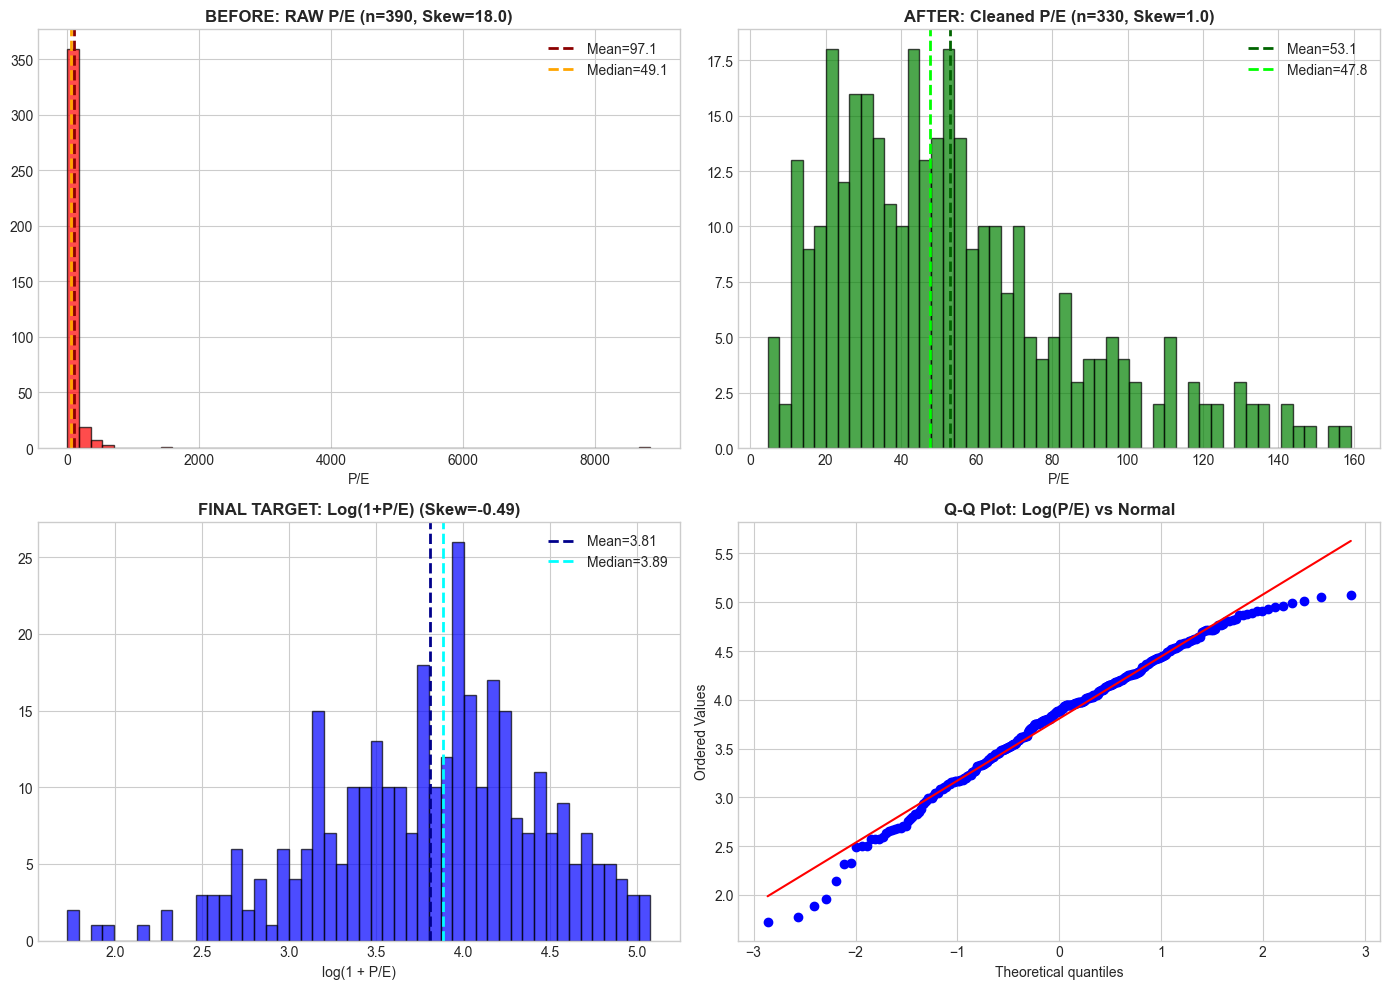


 COMPARISON TABLE:
Metric                   RAW      CLEANED          LOG
-------------------------------------------------------
Count                    390          330          330
Mean                   97.13        53.07         3.81
Median                 49.12        47.76         3.89
Std                   458.26        31.87         0.64
Skewness               18.04         1.00        -0.49
Max                  8839.48       159.19         5.08

 Skewness reduced from 18.0 → -0.49 after cleaning and log transform!


In [11]:
# 4.1 Cleaned P/E Distribution - Before vs After Comparison
print("="*70)
print(" P/E DISTRIBUTION: BEFORE vs AFTER CLEANING")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Original P/E (raw data)
ax1 = axes[0, 0]
ax1.hist(df_raw['P_E'], bins=50, edgecolor='black', alpha=0.7, color='red')
ax1.axvline(df_raw['P_E'].mean(), color='darkred', linestyle='--', lw=2, label=f'Mean={df_raw["P_E"].mean():.1f}')
ax1.axvline(df_raw['P_E'].median(), color='orange', linestyle='--', lw=2, label=f'Median={df_raw["P_E"].median():.1f}')
ax1.set_title(f'BEFORE: RAW P/E (n={len(df_raw)}, Skew={df_raw["P_E"].skew():.1f})', fontsize=12, fontweight='bold')
ax1.set_xlabel('P/E')
ax1.legend()

# 2. Cleaned P/E (after outlier removal)
ax2 = axes[0, 1]
ax2.hist(df_clean['P_E'], bins=50, edgecolor='black', alpha=0.7, color='green')
ax2.axvline(df_clean['P_E'].mean(), color='darkgreen', linestyle='--', lw=2, label=f'Mean={df_clean["P_E"].mean():.1f}')
ax2.axvline(df_clean['P_E'].median(), color='lime', linestyle='--', lw=2, label=f'Median={df_clean["P_E"].median():.1f}')
ax2.set_title(f'AFTER: Cleaned P/E (n={len(df_clean)}, Skew={df_clean["P_E"].skew():.1f})', fontsize=12, fontweight='bold')
ax2.set_xlabel('P/E')
ax2.legend()

# 3. Log-transformed P/E
ax3 = axes[1, 0]
ax3.hist(df_clean['P_E_log'], bins=50, edgecolor='black', alpha=0.7, color='blue')
ax3.axvline(df_clean['P_E_log'].mean(), color='darkblue', linestyle='--', lw=2, label=f'Mean={df_clean["P_E_log"].mean():.2f}')
ax3.axvline(df_clean['P_E_log'].median(), color='cyan', linestyle='--', lw=2, label=f'Median={df_clean["P_E_log"].median():.2f}')
ax3.set_title(f'FINAL TARGET: Log(1+P/E) (Skew={df_clean["P_E_log"].skew():.2f})', fontsize=12, fontweight='bold')
ax3.set_xlabel('log(1 + P/E)')
ax3.legend()

# 4. Q-Q Plot for normality check
ax4 = axes[1, 1]
stats.probplot(df_clean['P_E_log'], dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot: Log(P/E) vs Normal', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistics comparison
print("\n COMPARISON TABLE:")
print(f"{'Metric':<15} {'RAW':>12} {'CLEANED':>12} {'LOG':>12}")
print("-"*55)
print(f"{'Count':<15} {len(df_raw):>12} {len(df_clean):>12} {len(df_clean):>12}")
print(f"{'Mean':<15} {df_raw['P_E'].mean():>12.2f} {df_clean['P_E'].mean():>12.2f} {df_clean['P_E_log'].mean():>12.2f}")
print(f"{'Median':<15} {df_raw['P_E'].median():>12.2f} {df_clean['P_E'].median():>12.2f} {df_clean['P_E_log'].median():>12.2f}")
print(f"{'Std':<15} {df_raw['P_E'].std():>12.2f} {df_clean['P_E'].std():>12.2f} {df_clean['P_E_log'].std():>12.2f}")
print(f"{'Skewness':<15} {df_raw['P_E'].skew():>12.2f} {df_clean['P_E'].skew():>12.2f} {df_clean['P_E_log'].skew():>12.2f}")
print(f"{'Max':<15} {df_raw['P_E'].max():>12.2f} {df_clean['P_E'].max():>12.2f} {df_clean['P_E_log'].max():>12.2f}")

print("\n Skewness reduced from {:.1f} → {:.2f} after cleaning and log transform!".format(
    df_raw['P_E'].skew(), df_clean['P_E_log'].skew()))

 CLEANED DATA: SECTOR ANALYSIS

Sector distribution after cleaning:
Sector
Industrials               85
Materials                 64
Consumer Discretionary    41
Healthcare                38
Information Technology    31
Consumer Staples          28
Utilities                 16
Energy                    14
Communication Services     9
Financials                 4
Name: count, dtype: int64

 P/E Statistics by Sector (CLEANED DATA):
                        mean  median   std  count
Sector                                           
Consumer Staples       63.24   59.00 31.71     28
Consumer Discretionary 62.67   58.71 33.97     41
Healthcare             57.41   53.05 29.31     38
Communication Services 57.52   50.55 39.28      9
Financials             50.64   50.53  3.13      4
Industrials            54.56   47.86 28.74     85
Information Technology 55.55   45.92 32.21     31
Materials              46.77   42.08 29.58     64
Utilities              36.04   22.10 37.99     16
Energy          

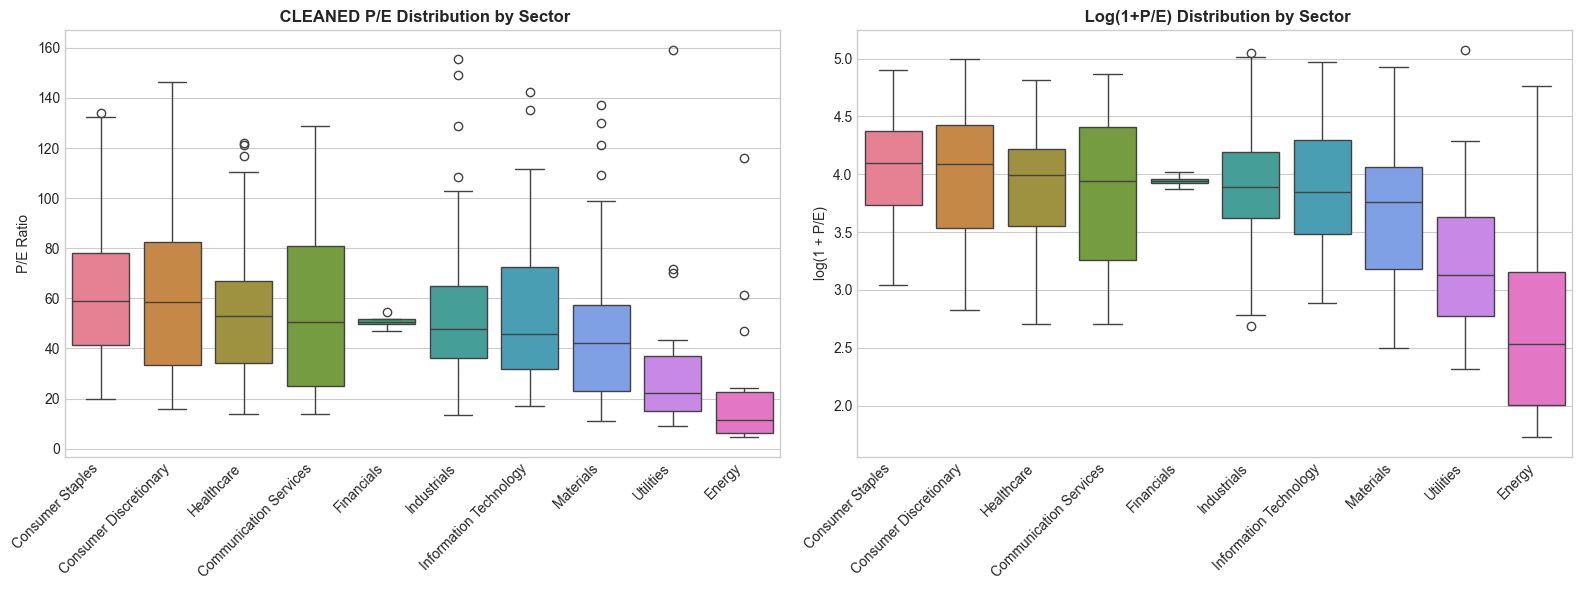

In [12]:
# 4.2 Cleaned Sector Distribution & P/E by Sector
print("="*70)
print(" CLEANED DATA: SECTOR ANALYSIS")
print("="*70)

# Sector counts after cleaning
sector_counts_clean = df_clean['Sector'].value_counts()
print(f"\nSector distribution after cleaning:")
print(sector_counts_clean)

# Sector-wise P/E statistics (cleaned)
sector_pe_clean = df_clean.groupby('Sector')['P_E'].agg(['mean', 'median', 'std', 'count'])
sector_pe_clean = sector_pe_clean.sort_values('median', ascending=False)
print(f"\n P/E Statistics by Sector (CLEANED DATA):")
print(sector_pe_clean.round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot - cleaned P/E by sector
ax1 = axes[0]
sector_order = sector_pe_clean.index.tolist()
sns.boxplot(data=df_clean, x='Sector', y='P_E', order=sector_order, ax=ax1, palette='husl')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_title(' CLEANED P/E Distribution by Sector', fontsize=12, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('P/E Ratio')

# Boxplot - log P/E by sector
ax2 = axes[1]
sns.boxplot(data=df_clean, x='Sector', y='P_E_log', order=sector_order, ax=ax2, palette='husl')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_title(' Log(1+P/E) Distribution by Sector', fontsize=12, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('log(1 + P/E)')

plt.tight_layout()
plt.show()

 SECTOR-WISE STATISTICS (CLEANED DATA)
                        P_E_mean  P_E_median  P_E_std  P_E_log_mean  \
Sector                                                                
Communication Services     57.52       50.55    39.28          3.84   
Consumer Discretionary     62.67       58.71    33.97          4.00   
Consumer Staples           63.24       59.00    31.71          4.03   
Energy                     24.36       11.63    31.37          2.75   
Financials                 50.64       50.53     3.13          3.94   
Healthcare                 57.41       53.05    29.31          3.95   
Industrials                54.56       47.86    28.74          3.89   
Information Technology     55.55       45.92    32.21          3.90   
Materials                  46.77       42.08    29.58          3.69   
Utilities                  36.04       22.10    37.99          3.30   

                        P_E_log_median  P_E_log_std  Sales_mean  Sales_median  \
Sector                     

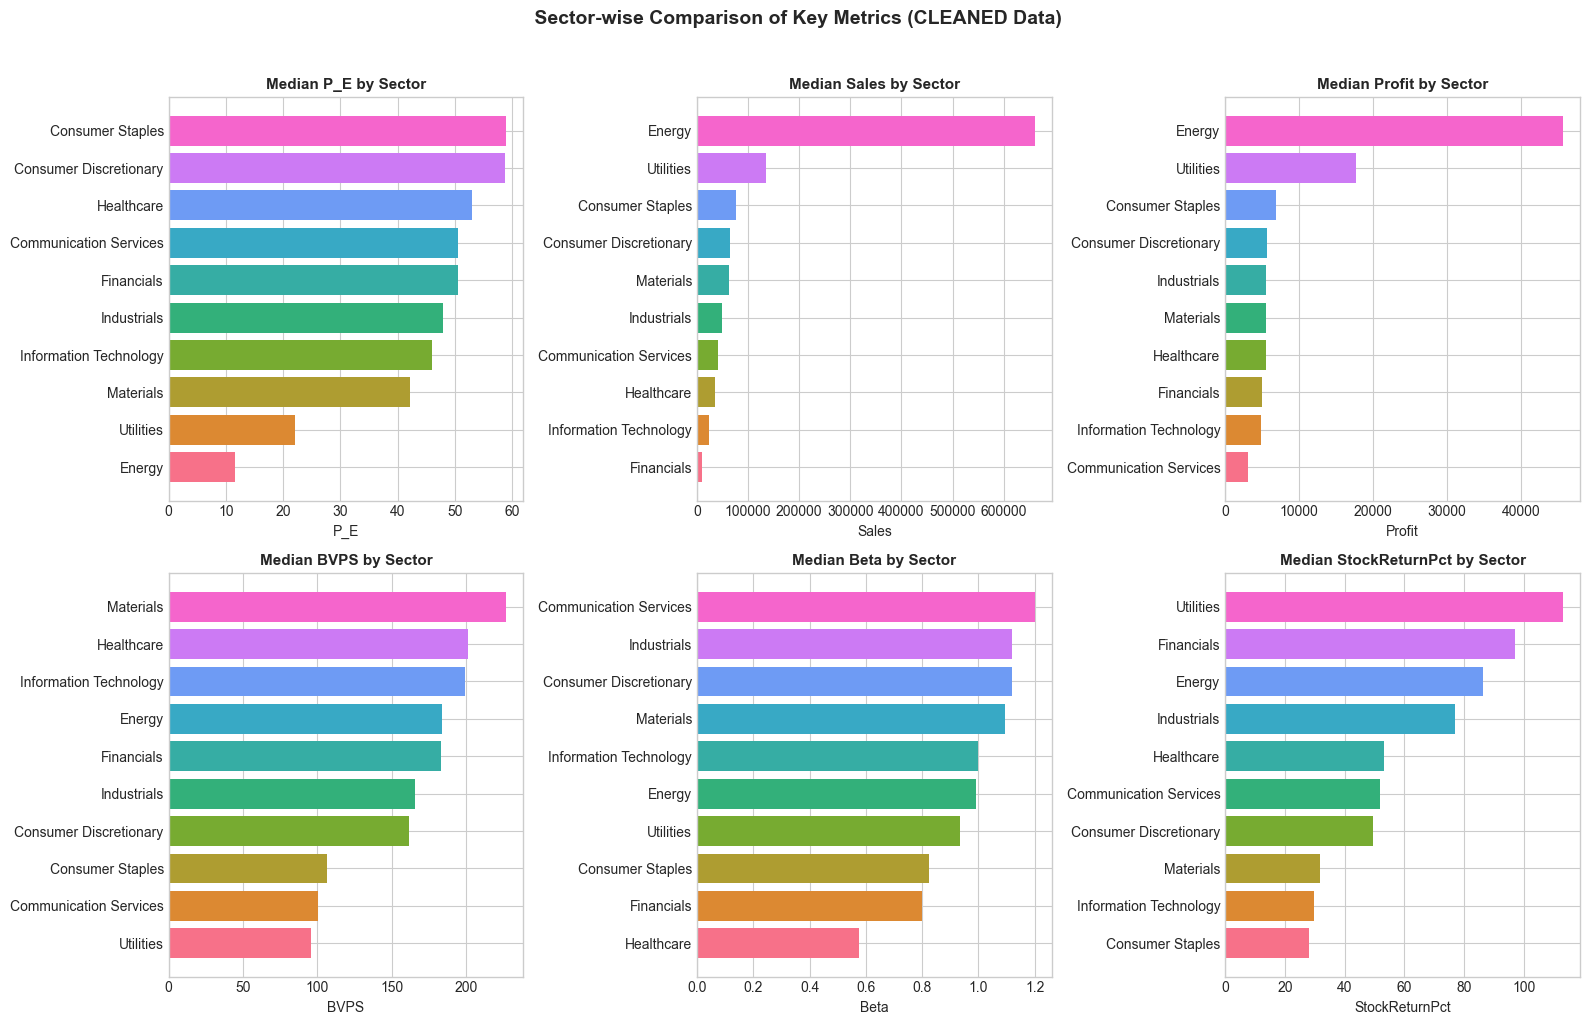


 SCATTER PLOTS: P/E vs KEY FEATURES (CLEANED DATA)


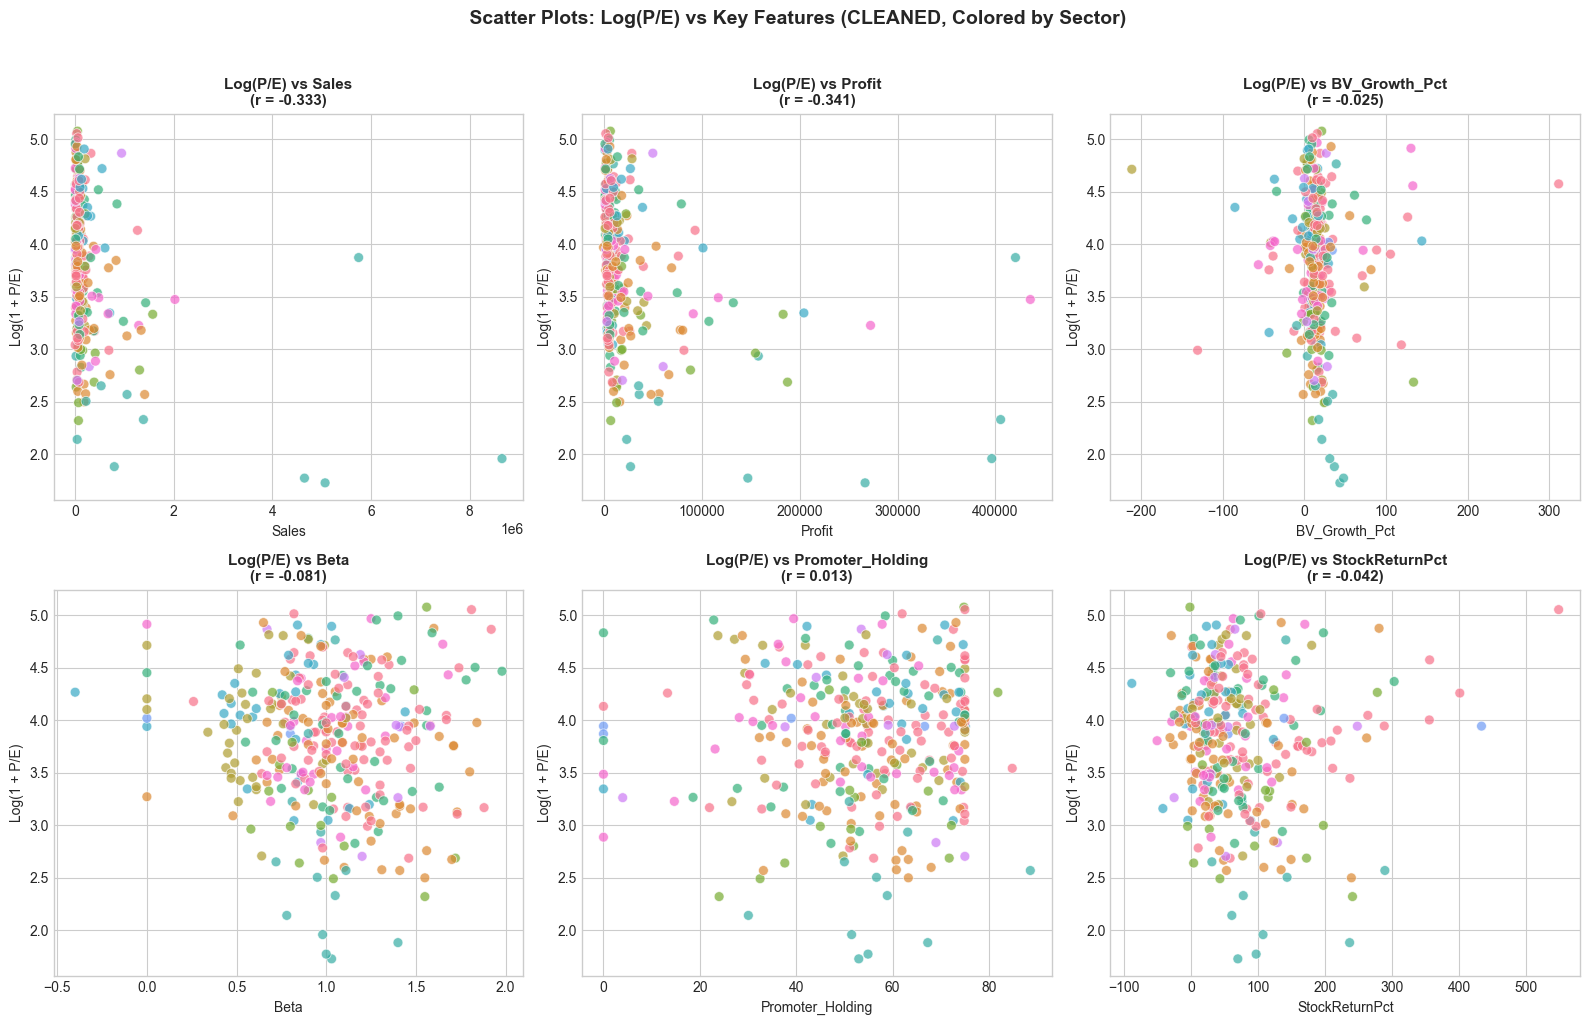


 Comparison with RAW data:
   - Outliers removed → cleaner relationships visible
   - Log transformation → more symmetric target distribution
   - Sector patterns more distinguishable


In [13]:
# 4.3 Sector-Level Aggregation (CLEANED Data)
print("="*70)
print(" SECTOR-WISE STATISTICS (CLEANED DATA)")
print("="*70)

key_metrics_clean = ['P_E', 'P_E_log', 'Sales', 'Profit', 'BVPS', 'Beta', 'StockReturnPct']

sector_agg_clean = df_clean.groupby('Sector')[key_metrics_clean].agg(['mean', 'median', 'std'])
sector_agg_clean.columns = ['_'.join(col) for col in sector_agg_clean.columns]
print(sector_agg_clean.round(2))

# Visualize sector comparisons for cleaned data
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_metrics = ['P_E', 'Sales', 'Profit', 'BVPS', 'Beta', 'StockReturnPct']
for idx, metric in enumerate(plot_metrics):
    ax = axes[idx]
    sector_medians = df_clean.groupby('Sector')[metric].median().sort_values(ascending=True)
    colors = sns.color_palette("husl", len(sector_medians))
    bars = ax.barh(sector_medians.index, sector_medians.values, color=colors)
    ax.set_title(f'Median {metric} by Sector', fontsize=11, fontweight='bold')
    ax.set_xlabel(metric)
    
plt.suptitle(' Sector-wise Comparison of Key Metrics (CLEANED Data)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Scatter plots for cleaned data
print("\n" + "="*70)
print(" SCATTER PLOTS: P/E vs KEY FEATURES (CLEANED DATA)")
print("="*70)

key_features_clean = ['Sales', 'Profit', 'BV_Growth_Pct', 'Beta', 'Promoter_Holding', 'StockReturnPct']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features_clean):
    ax = axes[idx]
    # Color by sector
    sns.scatterplot(data=df_clean, x=feature, y='P_E_log', hue='Sector', ax=ax, alpha=0.7, s=50)
    # Calculate correlation
    corr = df_clean[feature].corr(df_clean['P_E_log'])
    ax.set_title(f'Log(P/E) vs {feature}\n(r = {corr:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Log(1 + P/E)')
    ax.legend([], [], frameon=False)  # Hide legend for cleaner view

plt.suptitle(' Scatter Plots: Log(P/E) vs Key Features (CLEANED, Colored by Sector)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Comparison with RAW data:")
print("   - Outliers removed → cleaner relationships visible")
print("   - Log transformation → more symmetric target distribution")
print("   - Sector patterns more distinguishable")

---
## STEP 5: PREPROCESSING
Prepare data for modeling:
1. Define feature lists (excluding multicollinear features)
2. One-hot encode Sector
3. Scale numeric features
4. Create stratified K-Fold splits

In [14]:
# ============================================================
# STEP 5: PREPROCESSING
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

print("="*70)
print("🛠️ PREPROCESSING")
print("="*70)

# -----------------------------------------------
# 5.1 Define Feature Lists
# -----------------------------------------------
# EXCLUDING multicollinear features:
# - Total_Expenses (r=1.00 with Sales)
# - Total_Equity (r=0.80 with Profit)
# - Institutional_Holding (r=-0.81 with Promoter_Holding)
# ADDING engineered features

numeric_features = [
    # Original features (excluding multicollinear ones)
    'Promoter_Holding', 'Promoter_Pledged',  # Removed Institutional_Holding
    'Sales', 'Sales_Growth_Pct', 'BVPS', 'BV_Growth_Pct', 
    'Profit', 'Profit_Growth_Pct',  # Removed Total_Equity
    'Other_Income', 'RnD_Expenses',  # Removed Total_Expenses
    'Beta', 'StockReturnPct',
    # NEW engineered features
    'Profit_Margin', 'RnD_Intensity', 'OtherIncome_Ratio',
    'BV_Yield', 'Growth_Momentum', 'Promoter_Confidence'
]

categorical_features = ['Sector']
target = 'P_E_log'
id_col = 'Company_Name'

print(f"\n Feature Configuration:")
print(f"   Original features:    12 (after removing 3 multicollinear)")
print(f"   Engineered features:  6")
print(f"   Total numeric:        {len(numeric_features)}")
print(f"   Categorical:          {len(categorical_features)}")
print(f"   Target:               {target}")
print(f"\n    EXCLUDED (multicollinearity):")
print(f"      - Total_Expenses (r=1.00 with Sales)")
print(f"      - Total_Equity (r=0.80 with Profit)")
print(f"      - Institutional_Holding (r=-0.81 with Promoter_Holding)")

# -----------------------------------------------
# 5.2 One-Hot Encode Sector
# -----------------------------------------------
print("\n One-Hot Encoding Sector...")
df_encoded = pd.get_dummies(df_clean, columns=['Sector'], prefix='Sector', drop_first=False)

sector_dummies = [col for col in df_encoded.columns if col.startswith('Sector_')]
print(f"   Created {len(sector_dummies)} sector dummy variables")

# -----------------------------------------------
# 5.3 Prepare X and y
# -----------------------------------------------
feature_cols = numeric_features + sector_dummies
X = df_encoded[feature_cols].copy()
y = df_encoded[target].copy()

print(f"\n Feature matrix X shape: {X.shape}")
print(f" Target vector y shape: {y.shape}")

# Verify row count
assert len(X) == EXPECTED_ROWS, f"Row count mismatch! Expected {EXPECTED_ROWS}, got {len(X)}"
print(f" Row count verified: {len(X)} == {EXPECTED_ROWS}")

# -----------------------------------------------
# 5.4 Scale Numeric Features
# -----------------------------------------------
print("\n Scaling numeric features...")
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X[numeric_features])
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numeric_features, index=X.index)

# Combine scaled numeric with sector dummies (dummies don't need scaling)
X_scaled = pd.concat([X_numeric_scaled_df, X[sector_dummies]], axis=1)

print(f"   Scaled features shape: {X_scaled.shape}")
print(f"   Numeric features: mean ≈ 0, std ≈ 1 ")

# Final feature list
print(f"\n FINAL FEATURES ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")

🛠️ PREPROCESSING

 Feature Configuration:
   Original features:    12 (after removing 3 multicollinear)
   Engineered features:  6
   Total numeric:        18
   Categorical:          1
   Target:               P_E_log

    EXCLUDED (multicollinearity):
      - Total_Expenses (r=1.00 with Sales)
      - Total_Equity (r=0.80 with Profit)
      - Institutional_Holding (r=-0.81 with Promoter_Holding)

 One-Hot Encoding Sector...
   Created 10 sector dummy variables

 Feature matrix X shape: (330, 28)
 Target vector y shape: (330,)
 Row count verified: 330 == 330

 Scaling numeric features...
   Scaled features shape: (330, 28)
   Numeric features: mean ≈ 0, std ≈ 1 

 FINAL FEATURES (28):
    1. Promoter_Holding
    2. Promoter_Pledged
    3. Sales
    4. Sales_Growth_Pct
    5. BVPS
    6. BV_Growth_Pct
    7. Profit
    8. Profit_Growth_Pct
    9. Other_Income
   10. RnD_Expenses
   11. Beta
   12. StockReturnPct
   13. Profit_Margin
   14. RnD_Intensity
   15. OtherIncome_Ratio
   16. 

In [15]:
# 5.5 Stratified K-Fold Setup (by P/E bins + Sector)
print("="*70)
print(" STRATIFIED K-FOLD SETUP")
print("="*70)

# Discretize P/E into bins for stratification
n_bins = 5
y_binned = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')

print(f"\nTarget discretized into {n_bins} bins:")
bin_counts = pd.Series(y_binned).value_counts().sort_index()
for bin_id, count in bin_counts.items():
    bin_range = y[y_binned == bin_id]
    print(f"  Bin {bin_id}: {count} samples (P/E_log: {bin_range.min():.2f} - {bin_range.max():.2f})")

# Create combined stratification key: P/E bin + Sector
sector_labels = df_clean['Sector'].values
stratify_key = [f"{pe_bin}_{sector}" for pe_bin, sector in zip(y_binned, sector_labels)]
stratify_key = pd.Series(stratify_key)

print(f"\n Combined stratification groups: {stratify_key.nunique()}")

# Create 5-fold stratified CV
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)

# Store fold indices
folds = []
print(f"\n Creating {n_folds}-fold stratified split...")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_scaled, stratify_key)):
    folds.append({
        'fold': fold_idx + 1,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'train_size': len(train_idx),
        'val_size': len(val_idx)
    })
    print(f"  Fold {fold_idx + 1}: Train={len(train_idx)}, Val={len(val_idx)}")

print(f"\n Stratified K-Fold setup complete!")
print(f"   Stratified by: P/E bins AND Sectors")

 STRATIFIED K-FOLD SETUP

Target discretized into 5 bins:
  Bin 0: 66 samples (P/E_log: 1.73 - 3.26)
  Bin 1: 66 samples (P/E_log: 3.26 - 3.72)
  Bin 2: 66 samples (P/E_log: 3.75 - 4.00)
  Bin 3: 66 samples (P/E_log: 4.01 - 4.34)
  Bin 4: 66 samples (P/E_log: 4.35 - 5.08)

 Combined stratification groups: 44

 Creating 5-fold stratified split...
  Fold 1: Train=264, Val=66
  Fold 2: Train=264, Val=66
  Fold 3: Train=264, Val=66
  Fold 4: Train=264, Val=66
  Fold 5: Train=264, Val=66

 Stratified K-Fold setup complete!
   Stratified by: P/E bins AND Sectors


 STRATIFICATION BALANCE VISUALIZATION


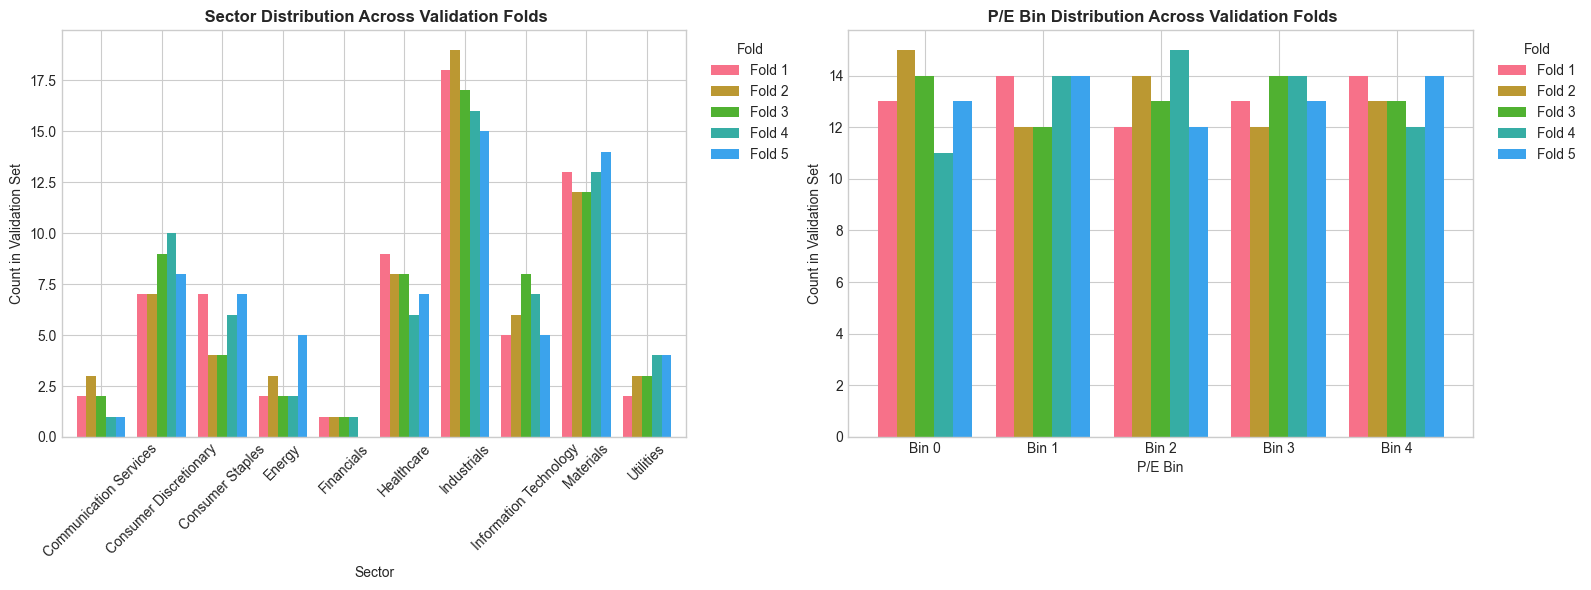


 Stratification ensures balanced distribution of both Sectors and P/E ranges across all folds!
   - Each fold has proportional sector representation
   - Each fold has balanced P/E bin distribution
   - This prevents data leakage and ensures fair model evaluation


In [16]:
# 5.6 Visualize Stratification Balance
print("="*70)
print(" STRATIFICATION BALANCE VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Sector distribution across folds
ax1 = axes[0]
fold_sector_data = []
for fold in folds:
    val_sectors = df_clean.iloc[fold['val_idx']]['Sector'].value_counts()
    for sector, cnt in val_sectors.items():
        fold_sector_data.append({'Fold': f"Fold {fold['fold']}", 'Sector': sector, 'Count': cnt})

fold_sector_df = pd.DataFrame(fold_sector_data)
fold_pivot = fold_sector_df.pivot(index='Sector', columns='Fold', values='Count').fillna(0)
fold_pivot.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title(' Sector Distribution Across Validation Folds', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sector')
ax1.set_ylabel('Count in Validation Set')
ax1.legend(title='Fold', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: P/E bin distribution across folds
ax2 = axes[1]
fold_pe_data = []
for fold in folds:
    val_pe_bins = y_binned.iloc[fold['val_idx']].value_counts()
    for pe_bin, cnt in val_pe_bins.items():
        fold_pe_data.append({'Fold': f"Fold {fold['fold']}", 'P/E Bin': f"Bin {pe_bin}", 'Count': cnt})

fold_pe_df = pd.DataFrame(fold_pe_data)
pe_pivot = fold_pe_df.pivot(index='P/E Bin', columns='Fold', values='Count').fillna(0)
pe_pivot.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title(' P/E Bin Distribution Across Validation Folds', fontsize=12, fontweight='bold')
ax2.set_xlabel('P/E Bin')
ax2.set_ylabel('Count in Validation Set')
ax2.legend(title='Fold', bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\n Stratification ensures balanced distribution of both Sectors and P/E ranges across all folds!")
print(f"   - Each fold has proportional sector representation")
print(f"   - Each fold has balanced P/E bin distribution")
print(f"   - This prevents data leakage and ensures fair model evaluation")

---
## STEP 6: MODEL BUILDING
Train and evaluate multiple regression models using 5-fold stratified cross-validation.

In [17]:
# 6.1 Import Models and Define Model Roster
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.base import clone
import time
from tqdm import tqdm

print(" Building REGRESSION model roster...")

MODEL_ROSTER = {
    # Linear Models
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=10.0, random_state=RANDOM_SEED),  # Increased regularization
    'Lasso': Lasso(alpha=0.5, random_state=RANDOM_SEED, max_iter=2000),  # Increased alpha
    'ElasticNet': ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=RANDOM_SEED, max_iter=2000),
    
    # Instance-based
    'KNN_5': KNeighborsRegressor(n_neighbors=5, n_jobs=-1, weights='distance'),
    'KNN_10': KNeighborsRegressor(n_neighbors=10, n_jobs=-1, weights='distance'),
    
    # Support Vector Machines
    'LinearSVR': LinearSVR(random_state=RANDOM_SEED, max_iter=2000, C=0.1),  # Lower C
    'SVR_RBF': SVR(kernel='rbf', C=0.5, epsilon=0.2),  # Lower C, higher epsilon
    
    # Tree-based (HEAVILY REGULARIZED)
    'DecisionTree': DecisionTreeRegressor(
        random_state=RANDOM_SEED, 
        max_depth=6,  # Reduced from 10
        min_samples_split=30, 
        min_samples_leaf=15  # Added leaf constraint
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=150, 
        random_state=RANDOM_SEED, 
        n_jobs=-1,
        max_depth=8,  # ADDED - critical regularization
        min_samples_leaf=10,  # ADDED
        max_features='sqrt'  # ADDED - reduces variance
    ),
    
    # Gradient Boosting (HEAVILY REGULARIZED)
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=100, 
        random_state=RANDOM_SEED,
        max_depth=4,  # ADDED - shallow trees
        min_samples_leaf=10,  # ADDED
        learning_rate=0.05,  # ADDED - slower learning
        subsample=0.8  # ADDED - row sampling
    ),
    'AdaBoost': AdaBoostRegressor(
        n_estimators=50,  # Reduced
        random_state=RANDOM_SEED,
        learning_rate=0.1  # ADDED - slower learning
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=150, 
        random_state=RANDOM_SEED, 
        verbosity=0,
        max_depth=4,  # ADDED - shallow trees
        min_child_weight=10,  # ADDED - regularization
        reg_alpha=0.5,  # ADDED - L1 regularization
        reg_lambda=1.0,  # ADDED - L2 regularization
        learning_rate=0.05,  # ADDED - slower
        subsample=0.8,  # ADDED - row sampling
        colsample_bytree=0.8  # ADDED - feature sampling
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=150, 
        random_state=RANDOM_SEED, 
        verbose=-1,
        max_depth=4,  # ADDED
        min_child_samples=15,  # ADDED
        reg_alpha=0.5,  # ADDED
        reg_lambda=1.0,  # ADDED
        learning_rate=0.05,  # ADDED
        subsample=0.8,  # ADDED
        colsample_bytree=0.8  # ADDED
    ),
    'CatBoost': cb.CatBoostRegressor(
        iterations=150, 
        random_state=RANDOM_SEED, 
        verbose=False,
        depth=4,  # ADDED - shallow trees
        l2_leaf_reg=5.0,  # ADDED - regularization
        learning_rate=0.05  # ADDED - slower
    ),
    
    # Neural Networks (REGULARIZED with early stopping, dropout-like)
    'MLP_Small': MLPRegressor(
        hidden_layer_sizes=(32, 16),  # Smaller
        random_state=RANDOM_SEED, 
        max_iter=500,
        alpha=1.0,  # ADDED - L2 regularization
        early_stopping=True,  # ADDED
        validation_fraction=0.15,
        n_iter_no_change=20
    ),
    'MLP_Medium': MLPRegressor(
        hidden_layer_sizes=(64, 32),  # Smaller
        random_state=RANDOM_SEED, 
        max_iter=500,
        alpha=1.0,  # ADDED - L2 regularization
        early_stopping=True,  # ADDED
        validation_fraction=0.15,
        n_iter_no_change=20
    ),
}

print(f" Model roster: {len(MODEL_ROSTER)} regression models")
for i, name in enumerate(MODEL_ROSTER.keys(), 1):
    print(f"  {i:2d}. {name}")

 Building REGRESSION model roster...
 Model roster: 17 regression models
   1. LinearRegression
   2. Ridge
   3. Lasso
   4. ElasticNet
   5. KNN_5
   6. KNN_10
   7. LinearSVR
   8. SVR_RBF
   9. DecisionTree
  10. RandomForest
  11. GradientBoosting
  12. AdaBoost
  13. XGBoost
  14. LightGBM
  15. CatBoost
  16. MLP_Small
  17. MLP_Medium


In [18]:
# 6.2 Define Evaluation Function
def evaluate_regression_model_cv(model, X, y, folds, model_name):
    """
    Evaluate a regression model using cross-validation.
    Returns comprehensive metrics including overfitting detection.
    """
    oof_predictions = np.zeros(len(y))
    fold_metrics = []
    train_metrics = []
    
    for fold_info in folds:
        fold_idx = fold_info['fold']
        train_idx = fold_info['train_idx']
        val_idx = fold_info['val_idx']
        
        # Split data
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Clone and fit model
        model_clone = clone(model)
        model_clone.fit(X_train, y_train)
        
        # Predictions
        y_train_pred = model_clone.predict(X_train)
        y_val_pred = model_clone.predict(X_val)
        
        # Store OOF predictions
        oof_predictions[val_idx] = y_val_pred
        
        # Validation metrics
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        val_mae = mean_absolute_error(y_val, y_val_pred)
        val_r2 = r2_score(y_val, y_val_pred)
        val_mape = mean_absolute_percentage_error(y_val, y_val_pred) * 100
        
        # Training metrics (for overfitting detection)
        train_r2 = r2_score(y_train, y_train_pred)
        
        fold_metrics.append({
            'fold': fold_idx, 'val_rmse': val_rmse, 'val_mae': val_mae,
            'val_r2': val_r2, 'val_mape': val_mape, 'train_r2': train_r2
        })
    
    # OOF metrics
    oof_rmse = np.sqrt(mean_squared_error(y, oof_predictions))
    oof_mae = mean_absolute_error(y, oof_predictions)
    oof_r2 = r2_score(y, oof_predictions)
    oof_mape = mean_absolute_percentage_error(y, oof_predictions) * 100
    
    # Generalization gap
    avg_train_r2 = np.mean([m['train_r2'] for m in fold_metrics])
    avg_val_r2 = np.mean([m['val_r2'] for m in fold_metrics])
    gen_gap = avg_train_r2 - avg_val_r2
    
    return {
        'model_name': model_name,
        'oof_metrics': {'rmse': oof_rmse, 'mae': oof_mae, 'r2': oof_r2, 'mape': oof_mape},
        'avg_train_r2': avg_train_r2,
        'avg_val_r2': avg_val_r2,
        'generalization_gap': gen_gap,
        'fold_metrics': fold_metrics
    }

print(" Evaluation function defined")

 Evaluation function defined


In [19]:
# 6.3 Run Model Evaluation Loop
print("="*70)
print(" STARTING MODEL EVALUATION")
print("="*70)
print(f"  Evaluating {len(MODEL_ROSTER)} models with 5-fold CV...")
print(f" Metrics: RMSE, MAE, R², MAPE, Generalization Gap\n")

model_results = {}
evaluation_summary = []
failed_models = []

total_start = time.time()

for model_name, model in tqdm(MODEL_ROSTER.items(), desc="Evaluating Models"):
    try:
        results = evaluate_regression_model_cv(
            model=model, X=X_scaled, y=y, folds=folds, model_name=model_name
        )
        model_results[model_name] = results
        
        metrics = results['oof_metrics']
        evaluation_summary.append({
            'Model': model_name,
            'RMSE': metrics['rmse'],
            'MAE': metrics['mae'],
            'R2': metrics['r2'],
            'MAPE': metrics['mape'],
            'Train_R2': results['avg_train_r2'],
            'Val_R2': results['avg_val_r2'],
            'Gen_Gap': results['generalization_gap'],
            'Status': 'Success'
        })
        
        # Status output
        gap_warning = " Overfitting!" if results['generalization_gap'] > 0.3 else ""
        print(f"   {model_name}: R²={metrics['r2']:.4f}, RMSE={metrics['rmse']:.3f}, Gap={results['generalization_gap']:.3f} {gap_warning}")
        
    except Exception as e:
        print(f"   {model_name} FAILED: {str(e)[:60]}")
        failed_models.append(model_name)
        evaluation_summary.append({
            'Model': model_name, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan,
            'MAPE': np.nan, 'Train_R2': np.nan, 'Val_R2': np.nan,
            'Gen_Gap': np.nan, 'Status': 'Failed'
        })

total_time = time.time() - total_start
print(f"\n Total time: {total_time:.1f} seconds")
print(f" Evaluated: {len(MODEL_ROSTER) - len(failed_models)}/{len(MODEL_ROSTER)} models")

 STARTING MODEL EVALUATION
  Evaluating 17 models with 5-fold CV...
 Metrics: RMSE, MAE, R², MAPE, Generalization Gap



Evaluating Models:  12%|█▏        | 2/17 [00:00<00:00, 16.36it/s]

   LinearRegression: R²=-3.1252, RMSE=1.294, Gap=3.573  Overfitting!
   Ridge: R²=-0.3891, RMSE=0.751, Gap=0.737  Overfitting!
   Lasso: R²=-0.0018, RMSE=0.638, Gap=0.005 
   ElasticNet: R²=-0.0014, RMSE=0.637, Gap=0.008 


Evaluating Models:  35%|███▌      | 6/17 [00:02<00:05,  2.05it/s]

   KNN_5: R²=0.0988, RMSE=0.605, Gap=0.917  Overfitting!
   KNN_10: R²=0.1481, RMSE=0.588, Gap=0.859  Overfitting!
   LinearSVR: R²=-2.1688, RMSE=1.134, Gap=2.483  Overfitting!


...

   CatBoost: R²=0.6637, RMSE=0.369, Gap=0.193 


Evaluating Models:  94%|█████████▍| 16/17 [00:09<00:00,  1.10it/s]

   MLP_Small: R²=-0.0787, RMSE=0.662, Gap=0.569  Overfitting!


Evaluating Models: 100%|██████████| 17/17 [00:11<00:00,  1.53it/s]

   MLP_Medium: R²=-0.2331, RMSE=0.707, Gap=0.403  Overfitting!

 Total time: 11.1 seconds
 Evaluated: 17/17 models


 MODEL LEADERBOARD

 COMPREHENSIVE MODEL LEADERBOARD (Sorted by R²):
------------------------------------------------------------------------------------------
           Model      R2   RMSE    MAE    MAPE  Train_R2  Val_R2  Gen_Gap
GradientBoosting  0.8366 0.2575 0.1740  5.0016    0.9566  0.8416   0.1150
         XGBoost  0.8026 0.2830 0.1938  5.5583    0.9604  0.8075   0.1529
        LightGBM  0.7912 0.2910 0.2008  5.8005    0.9428  0.7951   0.1477
        CatBoost  0.6637 0.3694 0.2699  7.6430    0.8561  0.6636   0.1925
        AdaBoost  0.5556 0.4246 0.3233  9.1859    0.7096  0.5507   0.1590
    DecisionTree  0.4665 0.4653 0.3493 10.0128    0.7124  0.4705   0.2419
    RandomForest  0.3978 0.4943 0.3795 10.9720    0.5712  0.3979   0.1732
          KNN_10  0.1481 0.5879 0.4696 13.4577    1.0000  0.1407   0.8593
         SVR_RBF  0.1191 0.5978 0.4671 13.4030    0.4211  0.1136   0.3075
           KNN_5  0.0988 0.6047 0.4798 13.5791    1.0000  0.0834   0.9166
      ElasticNet -0.0014 0

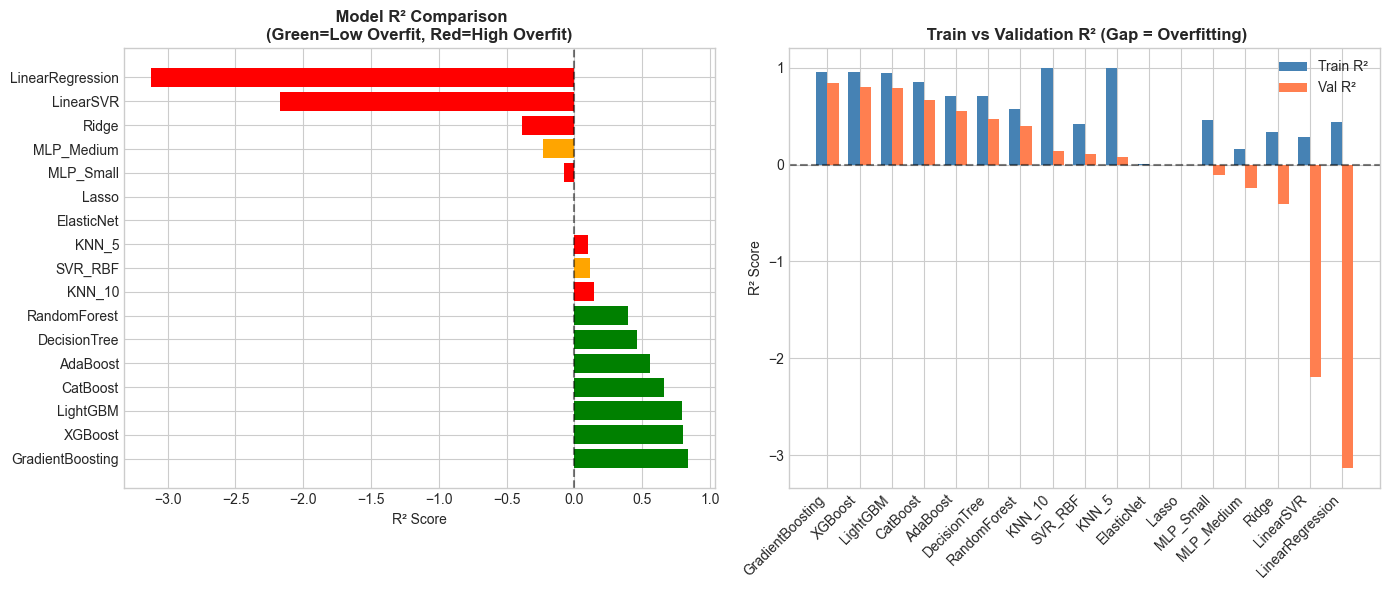


 Model evaluation complete!


In [20]:
# 6.4 Create Leaderboard and Analysis
print("="*70)
print(" MODEL LEADERBOARD")
print("="*70)

# Create leaderboard
leaderboard_df = pd.DataFrame(evaluation_summary)
leaderboard_df = leaderboard_df[leaderboard_df['Status'] == 'Success']
leaderboard_df = leaderboard_df.sort_values('R2', ascending=False)

# Display
print("\n COMPREHENSIVE MODEL LEADERBOARD (Sorted by R²):")
print("-"*90)
display_cols = ['Model', 'R2', 'RMSE', 'MAE', 'MAPE', 'Train_R2', 'Val_R2', 'Gen_Gap']
print(leaderboard_df[display_cols].to_string(index=False, float_format='%.4f'))

# Best model analysis
if len(leaderboard_df) > 0:
    best = leaderboard_df.iloc[0]
    print(f"\n BEST MODEL: {best['Model']}")
    print(f"   R²:    {best['R2']:.4f}")
    print(f"   RMSE:  {best['RMSE']:.4f}")
    print(f"   MAE:   {best['MAE']:.4f}")
    print(f"   Generalization Gap: {best['Gen_Gap']:.4f}")
    
    # Find best model with low overfitting
    low_overfit = leaderboard_df[leaderboard_df['Gen_Gap'] < 0.3]
    if len(low_overfit) > 0:
        best_stable = low_overfit.iloc[0]
        print(f"\n🎯 BEST STABLE MODEL (Gap < 0.3): {best_stable['Model']}")
        print(f"   R²:    {best_stable['R2']:.4f}")
        print(f"   Gap:   {best_stable['Gen_Gap']:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R² comparison
ax1 = axes[0]
colors = ['green' if g < 0.3 else 'orange' if g < 0.5 else 'red' for g in leaderboard_df['Gen_Gap']]
ax1.barh(leaderboard_df['Model'], leaderboard_df['R2'], color=colors)
ax1.set_xlabel('R² Score')
ax1.set_title(' Model R² Comparison\n(Green=Low Overfit, Red=High Overfit)', fontsize=12, fontweight='bold')
ax1.axvline(0, color='black', linestyle='--', alpha=0.5)

# Plot 2: Train vs Val R²
ax2 = axes[1]
x = range(len(leaderboard_df))
width = 0.35
ax2.bar([i - width/2 for i in x], leaderboard_df['Train_R2'], width, label='Train R²', color='steelblue')
ax2.bar([i + width/2 for i in x], leaderboard_df['Val_R2'], width, label='Val R²', color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(leaderboard_df['Model'], rotation=45, ha='right')
ax2.set_ylabel('R² Score')
ax2.set_title(' Train vs Validation R² (Gap = Overfitting)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n Model evaluation complete!")

---
## STEP 7: HYPERPARAMETER OPTIMIZATION (RandomizedSearchCV)
Tune the top 3 models using RandomizedSearchCV with cross-validation.

In [21]:
# 7.1 Hyperparameter Optimization using RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🔧 HYPERPARAMETER OPTIMIZATION (RandomizedSearchCV)")
print("="*70)

# Define search spaces for top 3 models
param_distributions = {
    'GradientBoosting': {
        'n_estimators': randint(100, 300),
        'max_depth': randint(3, 8),
        'min_samples_split': randint(10, 50),
        'min_samples_leaf': randint(5, 20),
        'learning_rate': uniform(0.01, 0.15),
        'subsample': uniform(0.6, 0.4),
        'max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'n_estimators': randint(100, 300),
        'max_depth': randint(3, 8),
        'min_child_weight': randint(5, 20),
        'learning_rate': uniform(0.01, 0.15),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 1.5)
    },
    'LightGBM': {
        'n_estimators': randint(100, 300),
        'max_depth': randint(3, 8),
        'num_leaves': randint(20, 50),
        'min_child_samples': randint(10, 30),
        'learning_rate': uniform(0.01, 0.15),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 1.5)
    }
}

# Base models to tune
base_models = {
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(random_state=RANDOM_SEED, verbose=-1)
}

# Run RandomizedSearchCV for each model
n_iter = 30  # Number of random combinations to try
cv_folds = 5

tuned_models = {}
tuning_results = []

print(f"\n Running RandomizedSearchCV with {n_iter} iterations, {cv_folds}-fold CV...\n")

for model_name, model in base_models.items():
    print(f" Tuning {model_name}...")
    start_time = time.time()
    
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[model_name],
        n_iter=n_iter,
        cv=cv_folds,
        scoring='r2',
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=0
    )
    
    random_search.fit(X_scaled, y)
    
    elapsed = time.time() - start_time
    
    # Store results
    tuned_models[model_name] = random_search.best_estimator_
    
    result = {
        'Model': model_name,
        'Best_R2_CV': random_search.best_score_,
        'Time_sec': elapsed,
        'Best_Params': random_search.best_params_
    }
    tuning_results.append(result)
    
    print(f" Best CV R²: {random_search.best_score_:.4f}")
    print(f" Time: {elapsed:.1f}s")
    print(f" Best params: {random_search.best_params_}\n")

# Summary table
print("\n" + "="*70)
print(" HPO RESULTS SUMMARY")
print("="*70)
tuning_df = pd.DataFrame(tuning_results)[['Model', 'Best_R2_CV', 'Time_sec']]
tuning_df = tuning_df.sort_values('Best_R2_CV', ascending=False)
print(tuning_df.to_string(index=False))

print("\n Hyperparameter optimization complete!")

🔧 HYPERPARAMETER OPTIMIZATION (RandomizedSearchCV)

 Running RandomizedSearchCV with 30 iterations, 5-fold CV...

 Tuning GradientBoosting...
 Best CV R²: 0.8852
 Time: 15.5s
 Best params: {'learning_rate': np.float64(0.10484587458903691), 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 18, 'n_estimators': 223, 'subsample': np.float64(0.8032795106962874)}

 Tuning XGBoost...
 Best CV R²: 0.8483
 Time: 5.0s
 Best params: {'colsample_bytree': np.float64(0.9932923543227152), 'learning_rate': np.float64(0.08001443398719699), 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 234, 'reg_alpha': np.float64(0.17052412368729153), 'reg_lambda': np.float64(0.5975773894779193), 'subsample': np.float64(0.9795542149013333)}

 Tuning LightGBM...
 Best CV R²: 0.8369
 Time: 13.5s
 Best params: {'colsample_bytree': np.float64(0.9452413703502374), 'learning_rate': np.float64(0.10349471902413368), 'max_depth': 4, 'min_child_samples': 10, 'n_estimators': 147, 'num_leav

 EVALUATING TUNED MODELS

 Evaluating tuned GradientBoosting...
   R²: 0.8923 | RMSE: 0.2091 | Gap: 0.1055

 Evaluating tuned XGBoost...
   R²: 0.8449 | RMSE: 0.2508 | Gap: 0.1514

 Evaluating tuned LightGBM...
   R²: 0.8486 | RMSE: 0.2478 | Gap: 0.1375

 TUNED MODELS LEADERBOARD
                 Model   R2  RMSE  MAE  MAPE  Train_R2  Val_R2  Gen_Gap
GradientBoosting_Tuned 0.89  0.21 0.14  3.96      1.00    0.89     0.11
        LightGBM_Tuned 0.85  0.25 0.16  4.68      0.99    0.85     0.14
         XGBoost_Tuned 0.84  0.25 0.16  4.64      1.00    0.85     0.15

 BASELINE vs TUNED COMPARISON
           Model  Baseline_R2  Tuned_R2  R2_Improvement  Baseline_Gap  Tuned_Gap  Gap_Change
GradientBoosting         0.84      0.89            0.06          0.12       0.11       -0.01
         XGBoost         0.80      0.84            0.04          0.15       0.15       -0.00
        LightGBM         0.79      0.85            0.06          0.15       0.14       -0.01


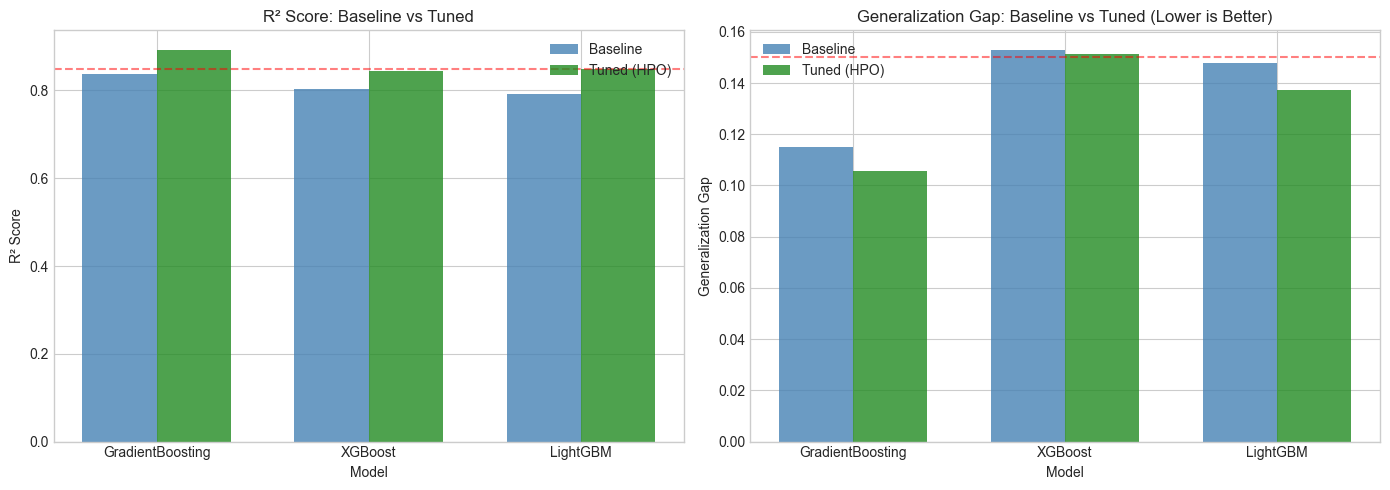


 Tuned model evaluation complete!


In [22]:
# 7.2 Evaluate Tuned Models with Cross-Validation
print("="*70)
print(" EVALUATING TUNED MODELS")
print("="*70)

tuned_evaluation = []

for model_name, model in tuned_models.items():
    print(f"\n Evaluating tuned {model_name}...")
    
    # Use our existing evaluation function
    result = evaluate_regression_model_cv(model, X_scaled, y, folds, model_name)
    
    # Extract metrics into flat structure
    metrics = {
        'Model': f"{model_name}_Tuned",
        'R2': result['oof_metrics']['r2'],
        'RMSE': result['oof_metrics']['rmse'],
        'MAE': result['oof_metrics']['mae'],
        'MAPE': result['oof_metrics']['mape'],
        'Train_R2': result['avg_train_r2'],
        'Val_R2': result['avg_val_r2'],
        'Gen_Gap': result['generalization_gap']
    }
    tuned_evaluation.append(metrics)
    
    print(f"   R²: {metrics['R2']:.4f} | RMSE: {metrics['RMSE']:.4f} | Gap: {metrics['Gen_Gap']:.4f}")

# Create comparison dataframe
tuned_eval_df = pd.DataFrame(tuned_evaluation)
tuned_eval_df = tuned_eval_df.sort_values('R2', ascending=False)

print("\n" + "="*70)
print(" TUNED MODELS LEADERBOARD")
print("="*70)
display_cols = ['Model', 'R2', 'RMSE', 'MAE', 'MAPE', 'Train_R2', 'Val_R2', 'Gen_Gap']
print(tuned_eval_df[display_cols].to_string(index=False))

# Compare with baseline
print("\n" + "="*70)
print(" BASELINE vs TUNED COMPARISON")
print("="*70)

baseline_models = ['GradientBoosting', 'XGBoost', 'LightGBM']
comparison_data = []

for model_name in baseline_models:
    # Get baseline from leaderboard (reset index to search by Model column)
    baseline_row = leaderboard_df.reset_index()
    baseline = baseline_row[baseline_row['Model'] == model_name].iloc[0]
    tuned = tuned_eval_df[tuned_eval_df['Model'] == f"{model_name}_Tuned"].iloc[0]
    
    comparison_data.append({
        'Model': model_name,
        'Baseline_R2': baseline['R2'],
        'Tuned_R2': tuned['R2'],
        'R2_Improvement': tuned['R2'] - baseline['R2'],
        'Baseline_Gap': baseline['Gen_Gap'],
        'Tuned_Gap': tuned['Gen_Gap'],
        'Gap_Change': tuned['Gen_Gap'] - baseline['Gen_Gap']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
x = np.arange(len(baseline_models))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, comparison_df['Baseline_R2'], width, label='Baseline', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, comparison_df['Tuned_R2'], width, label='Tuned (HPO)', color='forestgreen', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('R² Score')
ax1.set_title('R² Score: Baseline vs Tuned')
ax1.set_xticks(x)
ax1.set_xticklabels(baseline_models)
ax1.legend()
ax1.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target')

# Generalization Gap comparison
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, comparison_df['Baseline_Gap'], width, label='Baseline', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x + width/2, comparison_df['Tuned_Gap'], width, label='Tuned (HPO)', color='forestgreen', alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('Generalization Gap')
ax2.set_title('Generalization Gap: Baseline vs Tuned (Lower is Better)')
ax2.set_xticks(x)
ax2.set_xticklabels(baseline_models)
ax2.legend()
ax2.axhline(y=0.15, color='red', linestyle='--', alpha=0.5, label='Target')

plt.tight_layout()
plt.show()

print("\n Tuned model evaluation complete!")

---
## STEP 8: ENSEMBLE METHODS
Combine the tuned models using Voting and Stacking ensembles for potentially better performance.

In [23]:
# 8.1 Create Ensemble Models
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV

print("="*70)
print(" ENSEMBLE METHODS")
print("="*70)

# Get the tuned models
gb_tuned = tuned_models['GradientBoosting']
xgb_tuned = tuned_models['XGBoost']
lgb_tuned = tuned_models['LightGBM']

# -----------------------------------------------
# 8.1.1 Voting Regressor (Average of predictions)
# -----------------------------------------------
print("\n Creating Voting Regressor (Averaging)...")

voting_reg = VotingRegressor(
    estimators=[
        ('gb', clone(gb_tuned)),
        ('xgb', clone(xgb_tuned)),
        ('lgb', clone(lgb_tuned))
    ],
    n_jobs=-1
)

print(" VotingRegressor created with 3 base models")

# -----------------------------------------------
# 8.1.2 Weighted Voting Regressor
# -----------------------------------------------
print("\n Creating Weighted Voting Regressor...")

# Use R² scores as weights (normalized)
r2_scores = tuned_eval_df.set_index('Model')['R2']
gb_r2 = r2_scores['GradientBoosting_Tuned']
xgb_r2 = r2_scores['XGBoost_Tuned']
lgb_r2 = r2_scores['LightGBM_Tuned']

total_r2 = gb_r2 + xgb_r2 + lgb_r2
weights = [gb_r2/total_r2, xgb_r2/total_r2, lgb_r2/total_r2]

print(f"   Weights: GB={weights[0]:.3f}, XGB={weights[1]:.3f}, LGB={weights[2]:.3f}")

weighted_voting_reg = VotingRegressor(
    estimators=[
        ('gb', clone(gb_tuned)),
        ('xgb', clone(xgb_tuned)),
        ('lgb', clone(lgb_tuned))
    ],
    weights=weights,
    n_jobs=-1
)

print(" Weighted VotingRegressor created")

# -----------------------------------------------
# 8.1.3 Stacking Regressor
# -----------------------------------------------
print("\n Creating Stacking Regressor...")

# Use RidgeCV as meta-learner (robust to multicollinearity in base model predictions)
stacking_reg = StackingRegressor(
    estimators=[
        ('gb', clone(gb_tuned)),
        ('xgb', clone(xgb_tuned)),
        ('lgb', clone(lgb_tuned))
    ],
    final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0]),
    cv=5,
    n_jobs=-1,
    passthrough=False  # Only use base model predictions
)

print("StackingRegressor created with RidgeCV meta-learner")

# -----------------------------------------------
# 8.1.4 Stacking with Passthrough
# -----------------------------------------------
print("\nCreating Stacking Regressor with Passthrough...")

stacking_passthrough = StackingRegressor(
    estimators=[
        ('gb', clone(gb_tuned)),
        ('xgb', clone(xgb_tuned)),
        ('lgb', clone(lgb_tuned))
    ],
    final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0]),
    cv=5,
    n_jobs=-1,
    passthrough=True  # Include original features + base model predictions
)

print(" StackingRegressor (passthrough) created")

# Store all ensemble models
ensemble_models = {
    'Voting_Avg': voting_reg,
    'Voting_Weighted': weighted_voting_reg,
    'Stacking': stacking_reg,
    'Stacking_Passthrough': stacking_passthrough
}

print(f"\nCreated {len(ensemble_models)} ensemble models")

 ENSEMBLE METHODS

 Creating Voting Regressor (Averaging)...
 VotingRegressor created with 3 base models

 Creating Weighted Voting Regressor...
   Weights: GB=0.345, XGB=0.327, LGB=0.328
 Weighted VotingRegressor created

 Creating Stacking Regressor...
StackingRegressor created with RidgeCV meta-learner

Creating Stacking Regressor with Passthrough...
 StackingRegressor (passthrough) created

Created 4 ensemble models


In [24]:
# 8.2 Evaluate Ensemble Models
print("="*70)
print(" EVALUATING ENSEMBLE MODELS")
print("="*70)

ensemble_evaluation = []

for model_name, model in ensemble_models.items():
    print(f"\n Evaluating {model_name}...")
    start_time = time.time()
    
    try:
        # Evaluate using our existing function
        result = evaluate_regression_model_cv(model, X_scaled, y, folds, model_name)
        
        # Extract metrics into flat structure
        metrics = {
            'Model': model_name,
            'R2': result['oof_metrics']['r2'],
            'RMSE': result['oof_metrics']['rmse'],
            'MAE': result['oof_metrics']['mae'],
            'MAPE': result['oof_metrics']['mape'],
            'Train_R2': result['avg_train_r2'],
            'Val_R2': result['avg_val_r2'],
            'Gen_Gap': result['generalization_gap']
        }
        ensemble_evaluation.append(metrics)
        
        elapsed = time.time() - start_time
        gap_status = "ok" if metrics['Gen_Gap'] < 0.15 else "Not ok"
        print(f"   R²: {metrics['R2']:.4f} | RMSE: {metrics['RMSE']:.4f} | Gap: {metrics['Gen_Gap']:.4f} {gap_status}")
        print(f"   Time: {elapsed:.1f}s")
    except Exception as e:
        print(f"   Error Error: {str(e)}")

# Create ensemble leaderboard
ensemble_df = pd.DataFrame(ensemble_evaluation)
ensemble_df = ensemble_df.sort_values('R2', ascending=False)

print("\n" + "="*70)
print(" ENSEMBLE MODELS LEADERBOARD")
print("="*70)
display_cols = ['Model', 'R2', 'RMSE', 'MAE', 'MAPE', 'Train_R2', 'Val_R2', 'Gen_Gap']
print(ensemble_df[display_cols].to_string(index=False))

print("\n Ensemble evaluation complete!")

 EVALUATING ENSEMBLE MODELS

 Evaluating Voting_Avg...
   R²: 0.8770 | RMSE: 0.2234 | Gap: 0.1180 ok
   Time: 2.7s

 Evaluating Voting_Weighted...
   R²: 0.8775 | RMSE: 0.2230 | Gap: 0.1175 ok
   Time: 2.5s

 Evaluating Stacking...
   R²: 0.8967 | RMSE: 0.2048 | Gap: 0.0875 ok
   Time: 8.8s

 Evaluating Stacking_Passthrough...
   R²: 0.8730 | RMSE: 0.2270 | Gap: 0.0843 ok
   Time: 7.5s

 ENSEMBLE MODELS LEADERBOARD
               Model   R2  RMSE  MAE  MAPE  Train_R2  Val_R2  Gen_Gap
            Stacking 0.90  0.20 0.14  3.82      0.99    0.90     0.09
     Voting_Weighted 0.88  0.22 0.15  4.13      1.00    0.88     0.12
          Voting_Avg 0.88  0.22 0.15  4.14      1.00    0.88     0.12
Stacking_Passthrough 0.87  0.23 0.15  4.23      0.96    0.87     0.08

 Ensemble evaluation complete!


 FINAL MODEL COMPARISON

 ALL MODELS COMPARISON (Sorted by R²):
------------------------------------------------------------------------------------------
                    Model    Category   R2  RMSE  MAE  Gen_Gap
                 Stacking    Ensemble 0.90  0.20 0.14     0.09
   GradientBoosting_Tuned Tuned (HPO) 0.89  0.21 0.14     0.11
          Voting_Weighted    Ensemble 0.88  0.22 0.15     0.12
               Voting_Avg    Ensemble 0.88  0.22 0.15     0.12
     Stacking_Passthrough    Ensemble 0.87  0.23 0.15     0.08
           LightGBM_Tuned Tuned (HPO) 0.85  0.25 0.16     0.14
            XGBoost_Tuned Tuned (HPO) 0.84  0.25 0.16     0.15
GradientBoosting_Baseline    Baseline 0.84  0.26 0.17     0.12
         XGBoost_Baseline    Baseline 0.80  0.28 0.19     0.15
        LightGBM_Baseline    Baseline 0.79  0.29 0.20     0.15

 BEST OVERALL MODEL: Stacking
   Category: Ensemble
   R²:       0.8967
   RMSE:     0.2048
   MAE:      0.1382
   Gen Gap:  0.0875

 BEST STABLE MODEL

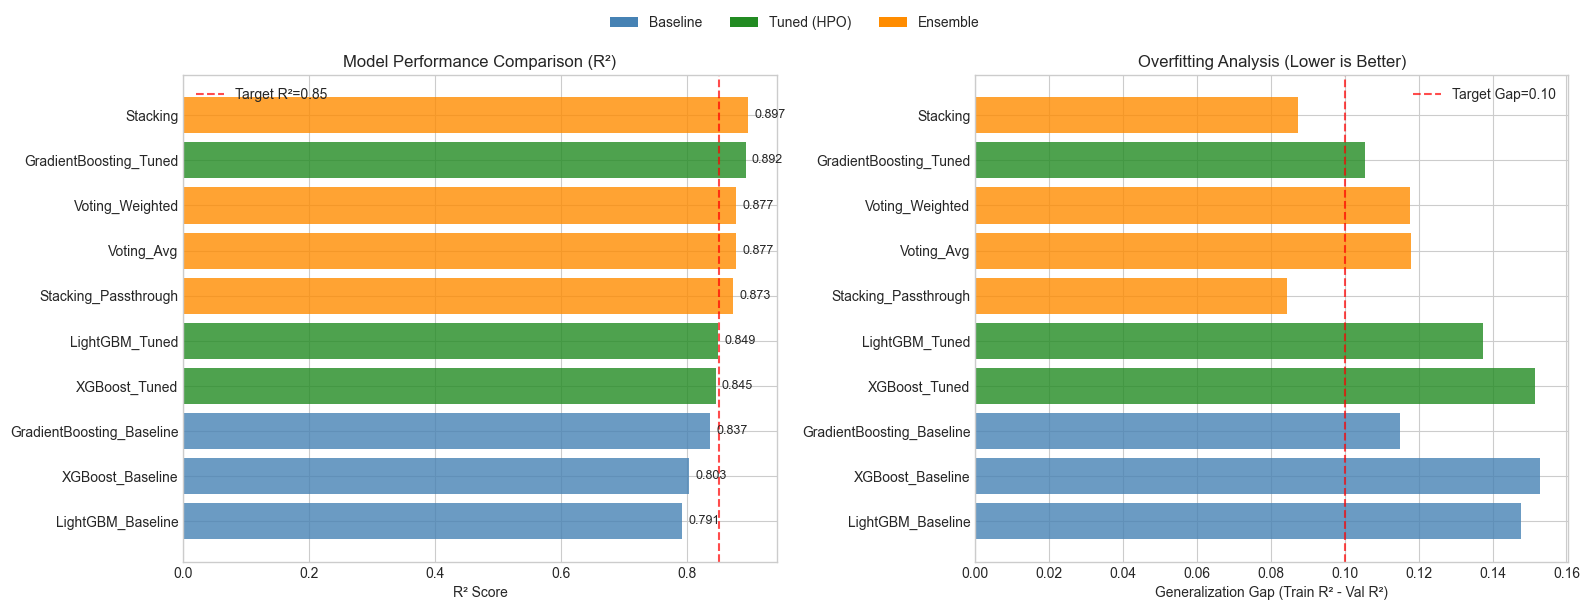


 SUMMARY
   Total models evaluated: 10
   Models with R² > 0.85:  5
   Models with Gap < 0.10: 2

 Final comparison complete!


In [25]:
# 8.3 Final Comparison: Baseline vs Tuned vs Ensemble
print("="*70)
print(" FINAL MODEL COMPARISON")
print("="*70)

# Combine all results
all_results = []

# Baseline models (top 3)
baseline_row = leaderboard_df.reset_index()
for model_name in ['GradientBoosting', 'XGBoost', 'LightGBM']:
    row = baseline_row[baseline_row['Model'] == model_name].iloc[0].to_dict()
    row['Model'] = f"{model_name}_Baseline"
    row['Category'] = 'Baseline'
    all_results.append(row)

# Tuned models
for _, row in tuned_eval_df.iterrows():
    row_copy = row.to_dict()
    row_copy['Category'] = 'Tuned (HPO)'
    all_results.append(row_copy)

# Ensemble models
for _, row in ensemble_df.iterrows():
    row_copy = row.to_dict()
    row_copy['Category'] = 'Ensemble'
    all_results.append(row_copy)

final_comparison = pd.DataFrame(all_results)
final_comparison = final_comparison.sort_values('R2', ascending=False)

print("\n ALL MODELS COMPARISON (Sorted by R²):")
print("-" * 90)
display_cols = ['Model', 'Category', 'R2', 'RMSE', 'MAE', 'Gen_Gap']
print(final_comparison[display_cols].to_string(index=False))

# Best overall model
best_model = final_comparison.iloc[0]
print("\n" + "="*70)
print(f" BEST OVERALL MODEL: {best_model['Model']}")
print("="*70)
print(f"   Category: {best_model['Category']}")
print(f"   R²:       {best_model['R2']:.4f}")
print(f"   RMSE:     {best_model['RMSE']:.4f}")
print(f"   MAE:      {best_model['MAE']:.4f}")
print(f"   Gen Gap:  {best_model['Gen_Gap']:.4f}")

# Best stable model (low overfitting)
stable_models = final_comparison[final_comparison['Gen_Gap'] < 0.10]
if len(stable_models) > 0:
    best_stable = stable_models.iloc[0]
    print(f"\n BEST STABLE MODEL (Gap < 0.10): {best_stable['Model']}")
    print(f"   R²: {best_stable['R2']:.4f} | Gap: {best_stable['Gen_Gap']:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color mapping
colors = {'Baseline': 'steelblue', 'Tuned (HPO)': 'forestgreen', 'Ensemble': 'darkorange'}
bar_colors = [colors[cat] for cat in final_comparison['Category']]

# R² comparison
ax1 = axes[0]
bars = ax1.barh(range(len(final_comparison)), final_comparison['R2'], color=bar_colors, alpha=0.8)
ax1.set_yticks(range(len(final_comparison)))
ax1.set_yticklabels(final_comparison['Model'])
ax1.set_xlabel('R² Score')
ax1.set_title('Model Performance Comparison (R²)')
ax1.axvline(x=0.85, color='red', linestyle='--', alpha=0.7, label='Target R²=0.85')
ax1.legend()
ax1.invert_yaxis()

# Add value labels
for i, (val, gap) in enumerate(zip(final_comparison['R2'], final_comparison['Gen_Gap'])):
    ax1.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

# Generalization Gap comparison
ax2 = axes[1]
bars2 = ax2.barh(range(len(final_comparison)), final_comparison['Gen_Gap'], color=bar_colors, alpha=0.8)
ax2.set_yticks(range(len(final_comparison)))
ax2.set_yticklabels(final_comparison['Model'])
ax2.set_xlabel('Generalization Gap (Train R² - Val R²)')
ax2.set_title('Overfitting Analysis (Lower is Better)')
ax2.axvline(x=0.10, color='red', linestyle='--', alpha=0.7, label='Target Gap=0.10')
ax2.legend()
ax2.invert_yaxis()

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[cat], label=cat) for cat in colors]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

print("\n" + "="*70)
print(" SUMMARY")
print("="*70)
print(f"   Total models evaluated: {len(final_comparison)}")
print(f"   Models with R² > 0.85:  {len(final_comparison[final_comparison['R2'] > 0.85])}")
print(f"   Models with Gap < 0.10: {len(final_comparison[final_comparison['Gen_Gap'] < 0.10])}")
print(f"\n Final comparison complete!")

---
## STEP 9: SECTOR RESIDUAL ANALYSIS
Where does market pricing systematically deviate from fundamentals?

Positive residual = market assigns a **premium** beyond what balance-sheet variables explain (brand moats, regulatory rents, intangibles).  
Negative residual = market assigns a **discount** vs fundamentals (cyclicality risk, governance concerns).

 SECTOR RESIDUAL ANALYSIS
 Actual P/E vs Model-Predicted P/E by Sector

 Positive = market premium beyond fundamentals
 Negative = market discount vs fundamentals
---------------------------------------------------------------------------
                        Count  Mean_Residual  Median_Resid  Mean_ActualPE  Mean_PredPE
Sector                                                                                
Utilities                  16           0.12          0.06          37.04        36.92
Consumer Staples           28           0.11          0.06          64.24        64.13
Information Technology     31           0.08         -0.02          56.55        56.47
Communication Services      9           0.06          0.03          58.52        58.46
Materials                  64           0.04          0.01          47.77        47.73
Healthcare                 38           0.03         -0.02          58.41        58.38
Industrials                85          -0.01          0.01       

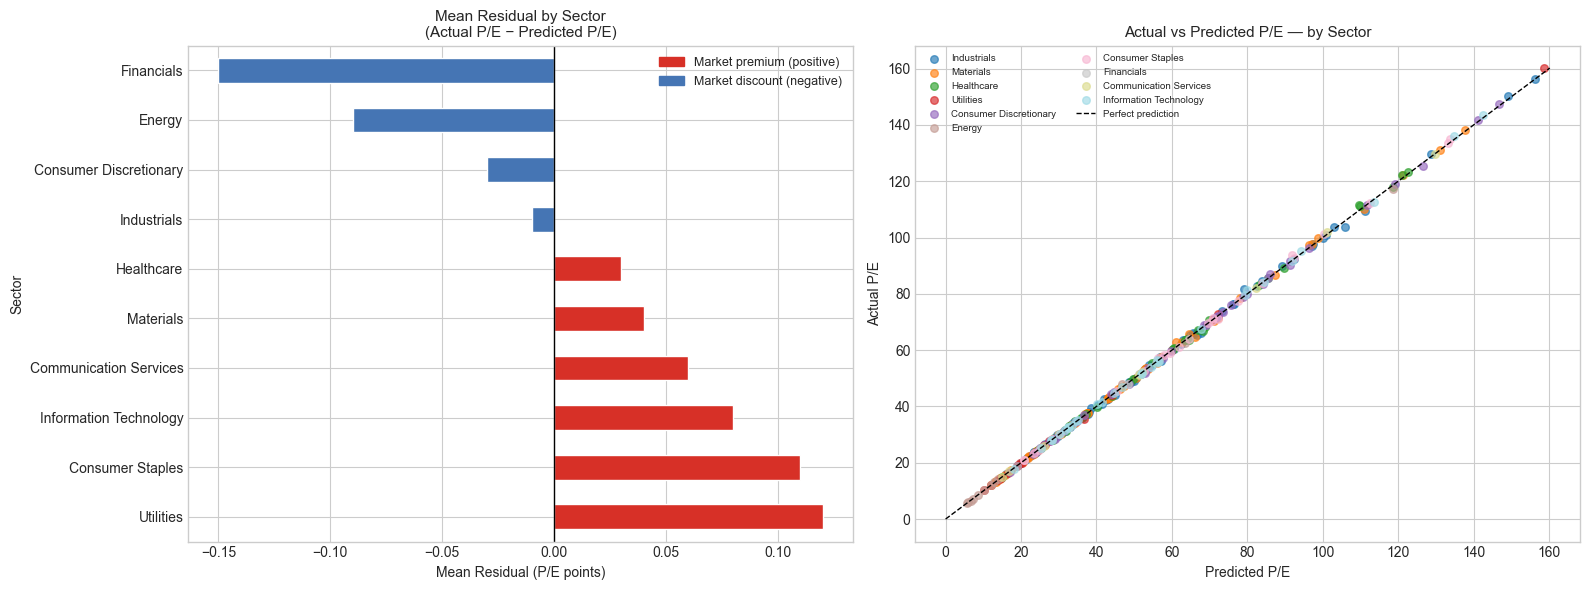


 KEY INSIGHT:
   Biggest premium sector : Utilities (+0.1 P/E points above model)
   Biggest discount sector: Financials (-0.1 P/E points below model)

   Interpretation: Utilities trades at a persistent premium to model predictions,
   suggesting brand intangibles / pricing power not captured in balance-sheet variables.
   Financials trades at a discount, consistent with cyclicality or governance risk.


In [26]:
# 9.1 Sector Residual Analysis
print("="*70)
print(" SECTOR RESIDUAL ANALYSIS")
print(" Actual P/E vs Model-Predicted P/E by Sector")
print("="*70)

import matplotlib.patches as mpatches

# Use best model (GradientBoosting_Tuned) — re-fit on full data
best_model = tuned_models['GradientBoosting']
best_model.fit(X_scaled, y)

# Predict and compute residuals in original P/E space
y_pred_log = best_model.predict(X_scaled)
residual_pe = np.exp(y.values) - np.exp(y_pred_log)

residual_df = pd.DataFrame({
    'Company_Name' : df_clean['Company_Name'].values,
    'Sector'       : df_clean['Sector'].values,
    'Actual_PE'    : np.exp(y.values),
    'Predicted_PE' : np.exp(y_pred_log),
    'Residual_PE'  : residual_pe
})

# Sector-level summary
sector_resid = residual_df.groupby('Sector').agg(
    Count         = ('Residual_PE', 'count'),
    Mean_Residual = ('Residual_PE', 'mean'),
    Median_Resid  = ('Residual_PE', 'median'),
    Mean_ActualPE = ('Actual_PE',   'mean'),
    Mean_PredPE   = ('Predicted_PE','mean'),
).round(2).sort_values('Mean_Residual', ascending=False)

print("\n Positive = market premium beyond fundamentals")
print(" Negative = market discount vs fundamentals")
print("-"*75)
print(sector_resid.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Mean residual bar chart
ax1 = axes[0]
colors = ['#d73027' if v > 0 else '#4575b4' for v in sector_resid['Mean_Residual']]
sector_resid['Mean_Residual'].plot(kind='barh', ax=ax1, color=colors, edgecolor='white')
ax1.axvline(0, color='black', lw=1)
ax1.set_title("Mean Residual by Sector\n(Actual P/E − Predicted P/E)", fontsize=11)
ax1.set_xlabel("Mean Residual (P/E points)", fontsize=10)
red_p  = mpatches.Patch(color='#d73027', label='Market premium (positive)')
blue_p = mpatches.Patch(color='#4575b4', label='Market discount (negative)')
ax1.legend(handles=[red_p, blue_p], fontsize=9)

# Chart 2: Actual vs Predicted scatter by sector
ax2 = axes[1]
sectors_unique = residual_df['Sector'].unique()
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors_unique)))
color_map = dict(zip(sectors_unique, palette))
for sector in sectors_unique:
    mask = residual_df['Sector'] == sector
    ax2.scatter(residual_df.loc[mask, 'Predicted_PE'],
                residual_df.loc[mask, 'Actual_PE'],
                color=color_map[sector], alpha=0.65, s=30, label=sector)
max_pe = residual_df[['Actual_PE','Predicted_PE']].max().max()
ax2.plot([0, max_pe], [0, max_pe], 'k--', lw=1, label='Perfect prediction')
ax2.set_xlabel("Predicted P/E", fontsize=10)
ax2.set_ylabel("Actual P/E", fontsize=10)
ax2.set_title("Actual vs Predicted P/E — by Sector", fontsize=11)
ax2.legend(fontsize=7, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

print("\n KEY INSIGHT:")
top_premium = sector_resid['Mean_Residual'].idxmax()
top_discount = sector_resid['Mean_Residual'].idxmin()
print(f"   Biggest premium sector : {top_premium} (+{sector_resid.loc[top_premium, 'Mean_Residual']:.1f} P/E points above model)")
print(f"   Biggest discount sector: {top_discount} ({sector_resid.loc[top_discount, 'Mean_Residual']:.1f} P/E points below model)")
print(f"\n   Interpretation: {top_premium} trades at a persistent premium to model predictions,")
print(f"   suggesting brand intangibles / pricing power not captured in balance-sheet variables.")
print(f"   {top_discount} trades at a discount, consistent with cyclicality or governance risk.")